# 🤖 Understanding AI Through Small Models
## What AI Can Do, What It Cannot, and Why It Matters

**What this notebook does:**
- Explains the relationship between AI, machine learning, and deep learning
- Walks you through downloading and running a real language model locally
- Demonstrates what small language models do well — and where they consistently fail
- Introduces RAG (Retrieval-Augmented Generation) as a practical fix for hallucination

> 🎯 **Who this notebook is for:** Learners with basic Python knowledge and no prior AI experience. You will run real models, not just read about them — every concept is demonstrated with live, editable code.

---

## 📋 Outline

| Part | Title | What you'll do |
|------|-------|----------------|
| **Part 0** | Introduction & Background | Understand AI/ML/DL relationships and why compute matters |
| **Part 1** | Setup | Install dependencies, download TinyLlama, run your first conversation |
| **Part 2** | What AI Can Do | Text generation, rewriting, and the effect of temperature |
| **Part 3** | What AI Cannot Do | Counting, reasoning, and hallucination — live experiments |
| **Part 4** | Giving AI a Memory | Use RAG to ground the model in your own documents |

---

⚠️ Before you start: Part 1 cells must be run in order — install → download → load → chat. Do not skip ahead. Parts 2–4 depend on Part 1 being completed first.

In [1]:
# ── CELL 1 ──────────────────────────────────────────────────
#@title Part 0 — Introduction

from IPython.display import display, HTML

display(HTML("""
<div style="font-family: -apple-system, sans-serif; margin: 20px 0;">

    <!-- Header -->
    <div style="background: #e8f4fd; padding: 32px; border-radius: 12px;
                border-left: 5px solid #1976d2; margin-bottom: 16px;">
        <h1 style="margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #0d47a1;">
            Understanding AI Through Small Models
        </h1>
        <p style="margin: 0; font-size: 15px; color: #555; line-height: 1.6;">
            What AI can do, what it cannot, and why it matters.
            No prior AI experience required. Basic Python knowledge assumed.
        </p>
    </div>

    <!-- Learning Objectives -->
    <div style="background: #f0f7ff; padding: 24px; border-radius: 12px;
                margin-bottom: 16px; border: 1px solid #bbdefb;">
        <h3 style="margin: 0 0 14px 0; font-size: 15px; color: #1565c0;
                   text-transform: uppercase; letter-spacing: 0.5px;">
            By the end of this notebook
        </h3>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px;">
            <div style="font-size: 14px; color: #333; line-height: 1.6;">
                Understand what language models are and how they work
            </div>
            <div style="font-size: 14px; color: #333; line-height: 1.6;">
                Recognize the systematic limitations of AI
            </div>
            <div style="font-size: 14px; color: #333; line-height: 1.6;">
                Run and interact with a local language model
            </div>
            <div style="font-size: 14px; color: #333; line-height: 1.6;">
                Use RAG to give AI access to your own information
            </div>
        </div>
    </div>

    <!-- Course Structure -->
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px;">
        <div style="background: #f8f9fa; padding: 18px; border-radius: 10px;
                    border: 1px solid #e0e0e0;">
            <div style="font-size: 11px; color: #888; text-transform: uppercase;
                        letter-spacing: 0.5px; margin-bottom: 6px;">Part 1</div>
            <div style="font-size: 14px; font-weight: 600; color: #222;">Setup</div>
            <div style="font-size: 13px; color: #666; margin-top: 4px;">
                Install, download, and run your first model
            </div>
        </div>
        <div style="background: #f8f9fa; padding: 18px; border-radius: 10px;
                    border: 1px solid #e0e0e0;">
            <div style="font-size: 11px; color: #888; text-transform: uppercase;
                        letter-spacing: 0.5px; margin-bottom: 6px;">Part 2</div>
            <div style="font-size: 14px; font-weight: 600; color: #222;">What AI Can Do</div>
            <div style="font-size: 13px; color: #666; margin-top: 4px;">
                Text generation, rewriting, temperature
            </div>
        </div>
        <div style="background: #f8f9fa; padding: 18px; border-radius: 10px;
                    border: 1px solid #e0e0e0;">
            <div style="font-size: 11px; color: #888; text-transform: uppercase;
                        letter-spacing: 0.5px; margin-bottom: 6px;">Part 3</div>
            <div style="font-size: 14px; font-weight: 600; color: #222;">What AI Cannot Do</div>
            <div style="font-size: 13px; color: #666; margin-top: 4px;">
                Counting, reasoning, hallucination
            </div>
        </div>
        <div style="background: #f8f9fa; padding: 18px; border-radius: 10px;
                    border: 1px solid #e0e0e0;">
            <div style="font-size: 11px; color: #888; text-transform: uppercase;
                        letter-spacing: 0.5px; margin-bottom: 6px;">Part 4</div>
            <div style="font-size: 14px; font-weight: 600; color: #222;">Giving AI a Memory</div>
            <div style="font-size: 13px; color: #666; margin-top: 4px;">
                RAG: using your own documents as context
            </div>
        </div>
    </div>


    <!-- Attribution -->
    <div style="margin-top: 16px; padding: 16px 20px; background: #f8f9fa;
                border-radius: 10px; border: 1px solid #e0e0e0;
                font-family: -apple-system, sans-serif; font-size: 13px; color: #555; line-height: 1.8;">
        Notebook developed by <strong>SzuLun Huang</strong>
        &lt;<a href="mailto:szuh@berkeley.edu" style="color: #1976d2;">szuh@berkeley.edu</a>&gt;<br>
        Under the guidance of <strong>Eric Van Dusen</strong>
        &lt;<a href="mailto:ericvd@berkeley.edu" style="color: #1976d2;">ericvd@berkeley.edu</a>&gt;<br>
        UC Berkeley, Data Science
    </div>

</div>
"""))

In [2]:
#@title AI, ML, DL - What's the Relationship?

from IPython.display import display, HTML

ai_evolution_pro = """
<style>
    :root {
        --ai-blue: #0071e3;
        --ml-green: #34c759;
        --dl-orange: #ff9500;
        --tf-purple: #bf5af2;
        --text-main: #1d1d1f;
        --text-sub: #86868b;
        --bg-light: #f5f5f7;
    }

    .ai-wrapper {
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
        padding: 40px;
        background-color: var(--bg-light);
        border-radius: 24px;
        color: var(--text-main);
    }

    /* --- Evolution Timeline --- */
    .evolution-line {
        display: flex;
        justify-content: space-between;
        margin: 60px 0 40px;
        position: relative;
        flex-wrap: wrap;
        gap: 10px;
    }

    .evolution-line::before {
        content: '';
        position: absolute;
        top: 50%; left: 2%; right: 2%;
        height: 1px;
        background: #d2d2d7;
        z-index: 1;
    }

    .time-node {
        position: relative;
        z-index: 2;
        background: white;
        padding: 8px 16px;
        border-radius: 12px;
        border: 1px solid #d2d2d7;
        font-size: 13px;
        font-weight: 600;
        color: var(--text-main);
    }

    .year-marker {
        position: absolute;
        bottom: -25px;
        left: 50%;
        transform: translateX(-50%);
        font-size: 11px;
        color: var(--text-sub);
        white-space: nowrap;
    }

    /* --- Interactive Cards --- */
    .grid-layout {
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(240px, 1fr));
        gap: 20px;
    }

    .tech-card {
        background: white;
        padding: 30px;
        border-radius: 20px;
        box-shadow: 0 4px 24px rgba(0,0,0,0.04);
        transition: all 0.4s cubic-bezier(0.4, 0, 0.2, 1);
        cursor: pointer;
        border: 1px solid transparent;
        overflow: hidden;
    }

    .tech-card:hover {
        transform: translateY(-8px);
        box-shadow: 0 12px 40px rgba(0,0,0,0.08);
    }

    .card-header {
        display: flex;
        align-items: center;
        margin-bottom: 12px;
    }

    .icon-box {
        width: 32px;
        height: 32px;
        margin-right: 12px;
        display: flex;
        align-items: center;
        justify-content: center;
    }

    .tech-title {
        font-size: 20px;
        font-weight: 700;
        margin: 0;
    }

    .tech-desc {
        font-size: 15px;
        color: var(--text-sub);
        margin: 0;
        line-height: 1.5;
    }

    /* Expanding Details */
    .tech-details {
        max-height: 0;
        opacity: 0;
        transition: all 0.5s ease;
        font-size: 14px;
        line-height: 1.6;
        border-top: 0px solid #f5f5f7;
        overflow: hidden;
    }

    .tech-card.is-expanded {
        border-color: #d2d2d7;
    }

    .tech-card.is-expanded .tech-details {
        max-height: 500px;
        opacity: 1;
        margin-top: 20px;
        padding-top: 20px;
        border-top-width: 1px;
    }

    code {
        background: #f5f5f7;
        padding: 2px 6px;
        border-radius: 4px;
        font-family: "SF Mono", Menlo, monospace;
        font-size: 12px;
        color: #bf4800;
    }

    .code-block {
        background: #1d1d1f;
        color: #f5f5f7;
        padding: 12px;
        border-radius: 8px;
        margin-top: 10px;
        font-size: 11px;
        overflow-x: auto;
        line-height: 1.5;
    }

    .detail-note {
        margin-top: 12px;
        font-size: 13px;
        color: var(--text-sub);
    }
</style>

<div class="ai-wrapper">
    <div style="max-width: 800px; margin: 0 auto; text-align: center; margin-bottom: 40px;">
        <h1 style="font-size: 32px; letter-spacing: -0.5px; margin: 0 0 10px 0;">Core Architecture</h1>
        <p style="color: var(--text-sub); font-size: 18px; margin: 0;">From Rule-Based Logic to Neural Intelligence</p>
    </div>

    <div class="evolution-line">
        <div class="time-node">Classical AI <span class="year-marker">1950s</span></div>
        <div class="time-node">Statistical ML <span class="year-marker">1980s</span></div>
        <div class="time-node">Deep Learning <span class="year-marker">2012</span></div>
        <div class="time-node" style="background: var(--tf-purple); color: white; border: none;">
            Transformers <span class="year-marker">2017</span>
        </div>
        <div class="time-node" style="background: var(--text-main); color: white; border: none;">
            ChatGPT Era <span class="year-marker">2022</span>
        </div>
    </div>

    <div class="grid-layout">
        <div class="tech-card" onclick="this.classList.toggle('is-expanded')">
            <div class="card-header">
                <div class="icon-box">
                    <svg width="24" height="24" viewBox="0 0 24 24" fill="none" stroke="var(--ai-blue)" stroke-width="2"><rect x="2" y="3" width="20" height="14" rx="2"/><line x1="8" y1="21" x2="16" y2="21"/><line x1="12" y1="17" x2="12" y2="21"/></svg>
                </div>
                <h3 class="tech-title" style="color: var(--ai-blue);">AI</h3>
            </div>
            <p class="tech-desc">The discipline of creating systems that simulate human intelligence</p>
            <div class="tech-details">
                <strong>Mechanism:</strong> Expert Systems with hand-written rules
                <div class="code-block">
if "password" in input and "reset" in input:<br>
&nbsp;&nbsp;&nbsp;&nbsp;return initiate_password_reset()<br>
elif "order" in input and "status" in input:<br>
&nbsp;&nbsp;&nbsp;&nbsp;return check_order_status()<br>
# Thousands of hand-written rules...
                </div>
                <p class="detail-note"><strong>Problem:</strong> Doesn't scale, breaks on unexpected inputs</p>
            </div>
        </div>

        <div class="tech-card" onclick="this.classList.toggle('is-expanded')">
            <div class="card-header">
                <div class="icon-box">
                    <svg width="24" height="24" viewBox="0 0 24 24" fill="none" stroke="var(--ml-green)" stroke-width="2"><path d="M21.21 15.89A10 10 0 1 1 8 2.83"/><path d="M22 12A10 10 0 0 0 12 2v10z"/></svg>
                </div>
                <h3 class="tech-title" style="color: var(--ml-green);">ML</h3>
            </div>
            <p class="tech-desc">Algorithms that learn patterns from structured data</p>
            <div class="tech-details">
                <strong>Mechanism:</strong> Statistical models learn from examples
                <div class="code-block">
# Train on examples<br>
model.fit(X_train, y_train)<br>
<br>
# Predict on new data<br>
prediction = model.predict(X_test)
                </div>
                <p class="detail-note"><strong>Examples:</strong> Spam filters, fraud detection, recommendation systems</p>
            </div>
        </div>

        <div class="tech-card" onclick="this.classList.toggle('is-expanded')">
            <div class="card-header">
                <div class="icon-box">
                    <svg width="24" height="24" viewBox="0 0 24 24" fill="none" stroke="var(--dl-orange)" stroke-width="2"><path d="M12 2L2 7l10 5 10-5-10-5zM2 17l10 5 10-5M2 12l10 5 10-5"/></svg>
                </div>
                <h3 class="tech-title" style="color: var(--dl-orange);">DL</h3>
            </div>
            <p class="tech-desc">Deep neural networks that process unstructured data</p>
            <div class="tech-details">
                <strong>Mechanism:</strong> Many layers of artificial neurons
                <div class="code-block">
model.add(Dense(512, activation='relu'))<br>
model.add(Dropout(0.2))<br>
model.add(Dense(256, activation='relu'))<br>
model.add(Dense(10, activation='softmax'))
                </div>
                <p class="detail-note"><strong>Powers:</strong> Image recognition (CNNs), speech recognition (RNNs)</p>
            </div>
        </div>

        <div class="tech-card" onclick="this.classList.toggle('is-expanded')">
            <div class="card-header">
                <div class="icon-box">
                    <svg width="24" height="24" viewBox="0 0 24 24" fill="none" stroke="var(--tf-purple)" stroke-width="2">
                        <polygon points="12 2 2 7 12 12 22 7 12 2"/>
                        <polyline points="2 17 12 22 22 17"/>
                        <polyline points="2 12 12 17 22 12"/>
                    </svg>
                </div>
                <h3 class="tech-title" style="color: var(--tf-purple);">Transformers</h3>
            </div>
            <p class="tech-desc">The architecture powering all modern language models</p>
            <div class="tech-details">
                <strong>Mechanism:</strong> Self-attention processes sequences in parallel
                <div class="code-block">
# "Attention" lets model focus on<br>
# relevant parts of the input<br>
attention = softmax(Q @ K.T / sqrt(d_k)) @ V
                </div>
                <p class="detail-note"><strong>Powers:</strong> GPT, BERT, Claude, Llama - all modern LLMs use this</p>
            </div>
        </div>
    </div>
</div>
"""

display(HTML(ai_evolution_pro))

# Transition to next section
transition = """
<div style="background: white; padding: 30px; border-radius: 16px; margin: 30px 0; border-left: 4px solid #667eea;">
    <p style="font-size: 16px; line-height: 1.7; margin: 0; color: #1d1d1f;">
        <strong>For this notebook, we're working in the "DL → Transformers" layer.</strong><br>
        Specifically, we'll use <strong>small Transformer-based language models</strong>
        that you can run locally to understand how modern AI really works - without needing
        massive GPUs or API costs.
    </p>
</div>
"""

display(HTML(transition))

In [3]:
#@title 🔍 Check-in 0.1 — AI vs ML vs DL
from IPython.display import display, HTML

display(HTML("""
<div style="font-family:-apple-system,sans-serif; max-width:860px;">

  <div style="background:#f0f7ff; border-left:4px solid #1976d2;
              padding:16px 20px; border-radius:8px; margin-bottom:14px;">
    <strong style="font-size:15px;">Before you run the next cell — make a prediction:</strong><br><br>
    <span style="font-size:14px; line-height:1.8;">Eric wants to predict which students will struggle on the midterm.<br><br>
<b>Option A:</b> He writes rules by hand — "if homework score &lt; 60% AND section attendance &lt; 3 → flag as at-risk."<br>
<b>Option B:</b> He feeds three semesters of past student records into a model and lets it find the pattern.<br>
<b>Option C:</b> He uses a deep neural network trained on millions of student records across every UC campus.<br><br>
Which option is classical AI? Which is ML? Which is Deep Learning?<br>
Where does TinyLlama fit in this picture?</span>
  </div>

  <textarea placeholder="Write your prediction here before revealing the answer..."
    style="width:100%; height:72px; padding:10px; font-size:13px; font-family:inherit;
           border:1px solid #ccc; border-radius:6px; resize:vertical; box-sizing:border-box;
           margin-bottom:10px;"></textarea>

  <details style="border:1px solid #c8e6c9; border-radius:8px; overflow:hidden;">
    <summary style="background:#e8f5e9; padding:11px 16px; cursor:pointer;
                    font-weight:600; font-size:14px; list-style:none; user-select:none;">
      &#9654; Reveal Answer
    </summary>
    <div style="padding:16px 20px; font-size:13px; line-height:1.8; color:#1d1d1f;">

<b>Option A</b> is classical AI — hand-written rules that encode Eric's intuition directly.<br>
<b>Option B</b> is Machine Learning — the model discovers patterns from data instead of following explicit rules.<br>
<b>Option C</b> is Deep Learning — a subset of ML using multi-layer neural networks that scale to massive datasets.<br><br>
<b>TinyLlama</b> is Deep Learning, specifically a Transformer.
It did not learn rules about language — it learned statistical patterns from an enormous amount of text,
the same way Option C learns from millions of student records.

    </div>
  </details>

</div>
"""))



THE REAL COSTS



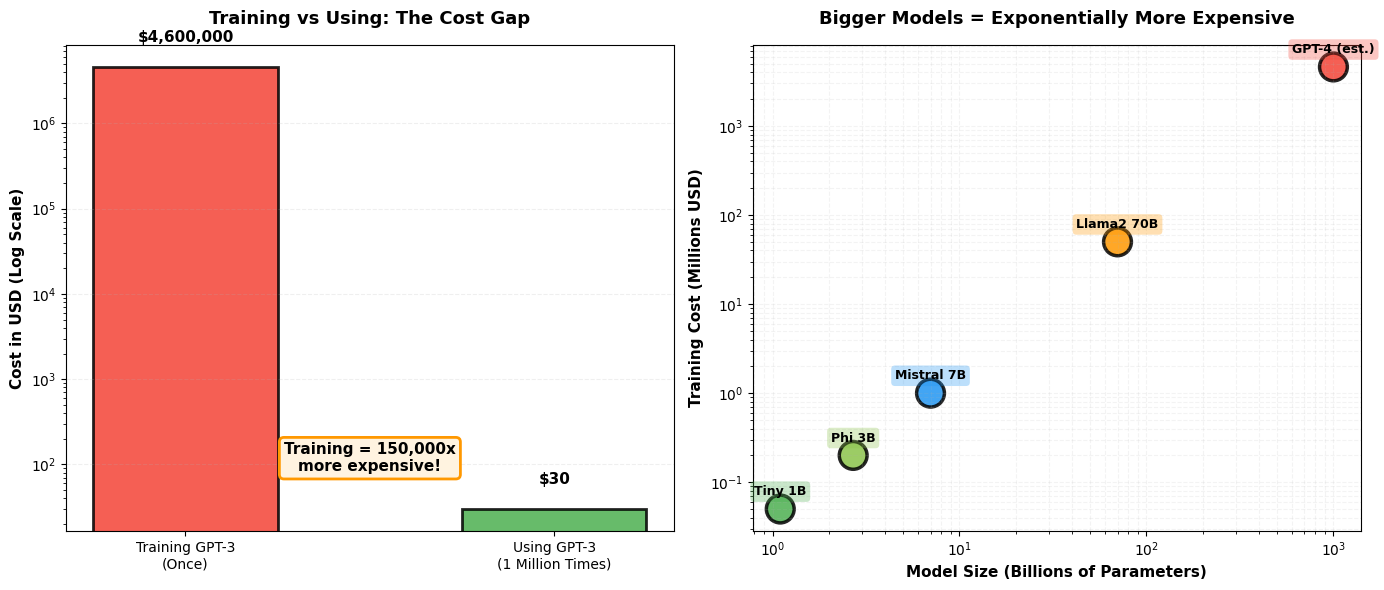


Key Facts:
• Training GPT-3 cost ~$4.6 million in compute
• Used 10,000 GPUs running for weeks
• GPT-4 is estimated to cost over $100 million to train
• Only big tech companies can afford this



✓ Part 0 Complete: Foundation Established

You now understand:
  • What AI/ML/DL are
  • Why big models are expensive
  • Why we're using small models

Next: Let's actually run some models!


In [4]:
#@title ⚡ Section 0.3: Why Does AI Need So Much Computing Power?

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# Apply styling
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.facecolor'] = 'white'

# Part 1: The Simple Story
intro_story = """
<style>
    .story-wrapper {
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
        padding: 40px;
        background: white;
        border-radius: 24px;
        border: 1px solid #d2d2d7;
        color: #1d1d1f;
        max-width: 900px;
        margin: 0 auto;
    }

    .story-header {
        text-align: center;
        margin-bottom: 40px;
    }

    .story-header h2 {
        font-size: 32px;
        font-weight: 700;
        margin: 0 0 10px 0;
    }

    .story-header p {
        font-size: 18px;
        color: #86868b;
        margin: 0;
    }

    .comparison-box {
        display: grid;
        grid-template-columns: 1fr 1fr;
        gap: 24px;
        margin: 30px 0;
    }

    .compare-item {
        padding: 25px;
        border-radius: 16px;
        border: 2px solid;
    }

    .compare-item.human {
        background: #e8f5e9;
        border-color: #4CAF50;
    }

    .compare-item.ai {
        background: #ffebee;
        border-color: #f44336;
    }

    .compare-item h3 {
        margin: 0 0 15px 0;
        font-size: 20px;
    }

    .compare-item .stat {
        font-size: 32px;
        font-weight: 700;
        color: #1d1d1f;
        margin: 10px 0;
    }

    .compare-item p {
        font-size: 14px;
        line-height: 1.6;
        color: #424242;
        margin: 5px 0;
    }

    .insight-box {
        background: #f5f5f7;
        padding: 20px;
        border-radius: 12px;
        margin: 20px 0;
        border-left: 4px solid #0071e3;
    }

    .insight-box p {
        margin: 0;
        font-size: 15px;
        line-height: 1.7;
        color: #1d1d1f;
    }
</style>

<div class="story-wrapper">
    <div class="story-header">
        <h2>Why Does AI Need So Much Power?</h2>
        <p>A Simple Analogy</p>
    </div>

    <h3 style="font-size: 22px; margin-bottom: 20px;">Learning to Recognize Cats</h3>

    <div class="comparison-box">
        <div class="compare-item human">
            <h3>👶 Human Child</h3>
            <p><strong>Training Data:</strong></p>
            <div class="stat">5 photos</div>
            <p><strong>Time:</strong> 5 minutes</p>
            <p><strong>Energy:</strong> 1 cookie</p>
            <p style="margin-top: 15px; font-style: italic;">Shows picture: "This is a cat"</p>
        </div>

        <div class="compare-item ai">
            <h3>🤖 AI Model</h3>
            <p><strong>Training Data:</strong></p>
            <div class="stat">1,000,000 photos</div>
            <p><strong>Time:</strong> Hours on GPUs</p>
            <p><strong>Energy:</strong> ~500 households for a day</p>
            <p style="margin-top: 15px; font-style: italic;">Needs massive examples to learn patterns</p>
        </div>
    </div>

    <div class="insight-box">
        <p><strong>Why the difference?</strong> Humans have built-in understanding of the world.
        AI starts with zero knowledge and learns purely from statistical patterns in data.
        It needs to see millions of examples to figure out what makes a "cat" a cat.</p>
    </div>
</div>
"""

display(HTML(intro_story))

# Part 2: The Numbers (Visualization)
print("\n" + "="*70)
print("THE REAL COSTS")
print("="*70 + "\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Training vs Using
stages = ['Training GPT-3\n(Once)', 'Using GPT-3\n(1 Million Times)']
costs = [4_600_000, 30]
colors = ['#f44336', '#4CAF50']

bars = ax1.bar(stages, costs, color=colors, width=0.5, alpha=0.85, edgecolor='black', linewidth=2)
ax1.set_yscale('log')
ax1.set_ylabel('Cost in USD (Log Scale)', fontweight='bold', fontsize=11)
ax1.set_title('Training vs Using: The Cost Gap', fontweight='bold', fontsize=13, pad=15)
ax1.grid(axis='y', alpha=0.2, linestyle='--')

# Add labels
for bar, cost in zip(bars, costs):
    height = bar.get_height()
    label = f'${cost:,.0f}'
    ax1.text(bar.get_x() + bar.get_width()/2., height * 1.8,
             label, ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add insight
ax1.text(0.5, 0.15, 'Training = 150,000x\nmore expensive!',
         transform=ax1.transAxes, ha='center', va='center',
         bbox=dict(boxstyle='round', facecolor='#fff3e0', edgecolor='#ff9800', linewidth=2),
         fontsize=11, fontweight='bold')

# Chart 2: Model Size vs Cost
models_short = ['Tiny\n1B', 'Phi\n3B', 'Mistral\n7B', 'Llama2\n70B', 'GPT-4\n(est.)']
params = np.array([1.1, 2.7, 7, 70, 1000])  # GPT-4 param count is unconfirmed; using ~1T as estimate
costs_mil = np.array([0.05, 0.2, 1, 50, 4600])
colors_models = ['#4CAF50', '#8BC34A', '#2196F3', '#FF9800', '#f44336']

scatter = ax2.scatter(params, costs_mil, s=400, c=colors_models,
                     alpha=0.85, edgecolors='black', linewidth=2.5)

ax2.set_xlabel('Model Size (Billions of Parameters)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Training Cost (Millions USD)', fontweight='bold', fontsize=11)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Bigger Models = Exponentially More Expensive', fontweight='bold', fontsize=13, pad=15)
ax2.grid(True, which="both", alpha=0.15, linestyle='--')

# Add labels
for model, x, y, color in zip(models_short, params, costs_mil, colors_models):
    ax2.annotate(model.replace('\n', ' '), (x, y),
                xytext=(0, 10), textcoords='offset points',
                fontsize=9, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3, edgecolor='none'))

plt.tight_layout()
plt.show()

print("\nKey Facts:")
print("• Training GPT-3 cost ~$4.6 million in compute")
print("• Used 10,000 GPUs running for weeks")
print("• GPT-4 is estimated to cost over $100 million to train")
print("• Only big tech companies can afford this")

# Part 3: Why This Matters (Simple Cards)
why_matters = """
<div class="story-wrapper" style="margin-top: 30px;">
    <div class="story-header">
        <h2>So Why Learn Small Models?</h2>
        <p>Because You Can Actually Use Them</p>
    </div>

    <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 20px; margin: 30px 0;">

        <div style="padding: 25px; background: #e8f5e9; border-radius: 16px; border-left: 4px solid #4CAF50;">
            <h3 style="margin: 0 0 12px 0; font-size: 18px;">It's Free</h3>
            <p style="margin: 0; font-size: 14px; line-height: 1.6; color: #424242;">
                TinyLlama runs on free Colab. No credit card, no API costs, no limits.
            </p>
        </div>

        <div style="padding: 25px; background: #e3f2fd; border-radius: 16px; border-left: 4px solid #2196F3;">
            <h3 style="margin: 0 0 12px 0; font-size: 18px;">It's Fast</h3>
            <p style="margin: 0; font-size: 14px; line-height: 1.6; color: #424242;">
                Get responses in seconds, not minutes. Perfect for learning and experimenting.
            </p>
        </div>

        <div style="padding: 25px; background: #f3e5f5; border-radius: 16px; border-left: 4px solid #9C27B0;">
            <h3 style="margin: 0 0 12px 0; font-size: 18px;">It's Educational</h3>
            <p style="margin: 0; font-size: 14px; line-height: 1.6; color: #424242;">
                Small models fail in obvious ways. Their mistakes teach you how AI really works.
            </p>
        </div>

        <div style="padding: 25px; background: #fff3e0; border-radius: 16px; border-left: 4px solid #FF9800;">
            <h3 style="margin: 0 0 12px 0; font-size: 18px;">Same Principles</h3>
            <p style="margin: 0; font-size: 14px; line-height: 1.6; color: #424242;">
                TinyLlama and GPT-4 use the same architecture. Learn on small, apply to large.
            </p>
        </div>
    </div>

    <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 35px; border-radius: 20px; color: white; text-align: center; margin-top: 40px;">
        <h3 style="margin: 0 0 15px 0; font-size: 24px;">The Bottom Line</h3>
        <p style="margin: 0; font-size: 16px; line-height: 1.7; opacity: 0.95;">
            You don't need millions of dollars to understand AI.<br>
            A 1B parameter model teaches you the same lessons as a 1T parameter model -<br>
            <strong>just faster, cheaper, and more honestly.</strong>
        </p>
    </div>
</div>
"""

display(HTML(why_matters))

# Final Transition
print("\n" + "="*70)
print("✓ Part 0 Complete: Foundation Established")
print("="*70)
print("\nYou now understand:")
print("  • What AI/ML/DL are")
print("  • Why big models are expensive")
print("  • Why we're using small models")
print("\nNext: Let's actually run some models!")

In [5]:
#@title 🔧 Part 1.1: Understanding the Ecosystem

from IPython.display import display, HTML

ecosystem_pro = """
<style>
    :root {
        --brand-blue: #0071e3;
        --brand-green: #34c759;
        --brand-orange: #ff9500;
        --text-main: #1d1d1f;
        --text-sub: #86868b;
        --bg-light: #f5f5f7;
    }

    .eco-wrapper {
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
        padding: 40px;
        background: white;
        border-radius: 24px;
        border: 1px solid #d2d2d7;
        color: var(--text-main);
    }

    .header-group {
        text-align: center;
        margin-bottom: 50px;
    }

    .header-group h2 {
        font-size: 32px;
        font-weight: 700;
        margin: 0 0 10px 0;
    }

    .header-group p {
        color: var(--text-sub);
        font-size: 18px;
        margin: 0;
    }

    /* Comparison Table */
    .comp-table {
        width: 100%;
        border-collapse: separate;
        border-spacing: 0;
        margin: 30px 0;
        border: 1px solid #d2d2d7;
        border-radius: 12px;
        overflow: hidden;
    }

    .comp-table th {
        background: var(--bg-light);
        padding: 16px;
        text-align: left;
        font-size: 13px;
        text-transform: uppercase;
        color: var(--text-sub);
        font-weight: 600;
        border-bottom: 1px solid #d2d2d7;
    }

    .comp-table td {
        padding: 16px;
        border-bottom: 1px solid #f5f5f7;
        font-size: 14px;
    }

    .comp-table tr:last-child td {
        border-bottom: none;
    }

    .comp-table tr:hover {
        background: #fafafa;
    }

    .tag-pro {
        color: var(--brand-green);
        font-weight: 600;
    }

    .tag-con {
        color: #ff3b30;
        font-weight: 600;
    }

    /* Tier Cards */
    .tier-grid {
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(280px, 1fr));
        gap: 24px;
        margin: 40px 0;
    }

    .tier-card {
        padding: 30px;
        border-radius: 20px;
        border: 1px solid #d2d2d7;
        background: white;
        transition: all 0.3s cubic-bezier(0.4, 0, 0.2, 1);
    }

    .tier-card:hover {
        transform: translateY(-5px);
        box-shadow: 0 10px 20px rgba(0,0,0,0.08);
    }

    .tier-card h4 {
        margin: 0 0 10px 0;
        font-size: 18px;
        font-weight: 600;
    }

    .tier-card .price {
        font-size: 32px;
        font-weight: 700;
        margin: 10px 0;
    }

    .tier-card .limit {
        font-size: 13px;
        color: #86868b;
        margin: 5px 0;
    }

    /* Workflow */
    .workflow {
        background: var(--bg-light);
        padding: 35px;
        border-radius: 20px;
        margin-top: 40px;
        border-left: 6px solid var(--brand-blue);
    }

    .workflow h3 {
        margin-top: 0;
        font-size: 22px;
        margin-bottom: 20px;
    }

    .step-container {
        display: flex;
        justify-content: center;
        align-items: center;
        margin-top: 30px;
        flex-wrap: wrap;
        gap: 20px;
    }

    .step {
        text-align: center;
        flex: 0 1 180px;
    }

    .step-icon {
        width: 56px;
        height: 56px;
        border-radius: 14px;
        display: flex;
        align-items: center;
        justify-content: center;
        margin: 0 auto 12px;
        font-size: 28px;
    }

    .arrow {
        color: #d2d2d7;
        font-size: 32px;
        flex-shrink: 0;
    }
</style>

<div class="eco-wrapper">
    <div class="header-group">
        <h2>The AI Access Ecosystem</h2>
        <p>Cloud APIs vs Local Models</p>
    </div>

    <table class="comp-table">
        <thead>
            <tr>
                <th>Feature</th>
                <th>Cloud API</th>
                <th>Local Models</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td><b>Setup Time</b></td>
                <td>5 minutes (sign up + API key)</td>
                <td><span class="tag-con">15 minutes</span> (download + install)</td>
            </tr>
            <tr>
                <td><b>Cost</b></td>
                <td><span class="tag-con">$0.002-0.03</span> per 1K tokens</td>
                <td><span class="tag-pro">$0</span> after download</td>
            </tr>
            <tr>
                <td><b>Privacy</b></td>
                <td>Data sent to company servers</td>
                <td><span class="tag-pro">100% local</span> - nothing leaves</td>
            </tr>
            <tr>
                <td><b>Speed</b></td>
                <td>1-3 seconds (network latency)</td>
                <td><span class="tag-pro">< 1 second</span></td>
            </tr>
            <tr>
                <td><b>Offline Use</b></td>
                <td><span class="tag-con">Requires internet</span></td>
                <td><span class="tag-pro">Works offline</span></td>
            </tr>
            <tr>
                <td><b>Learning Value</b></td>
                <td>Black box (can't see inside)</td>
                <td><span class="tag-pro">Transparent</span> - see how it works</td>
            </tr>
        </tbody>
    </table>

    <div class="tier-grid">
        <div class="tier-card" style="border-top: 4px solid #10a37f;">
            <h4>Cloud APIs</h4>
            <div class="price">$0.03/1K</div>
            <p class="limit">1 million tokens = $30</p>
            <p style="font-size: 14px; margin-top: 15px; line-height: 1.6;">
                <strong>Best for:</strong> Production apps, complex reasoning tasks
            </p>
            <p style="font-size: 12px; color: #86868b; margin-top: 10px;">
                Examples: GPT-4, Claude 3.5 Sonnet
            </p>
        </div>

        <div class="tier-card" style="border-top: 4px solid var(--brand-green);">
            <h4>Local Models</h4>
            <div class="price">$0</div>
            <p class="limit">Unlimited usage forever</p>
            <p style="font-size: 14px; margin-top: 15px; line-height: 1.6;">
                <strong>Best for:</strong> Learning, privacy, experimentation
            </p>
            <p style="font-size: 12px; color: #86868b; margin-top: 10px;">
                Examples: Llama 3, Phi-3, Mistral
            </p>
        </div>
    </div>

    <div class="workflow">
        <h3>Why llama.cpp + GGUF?</h3>
        <p style="font-size: 15px; line-height: 1.7; color: #424242;">
            To run models on free hardware (like Colab CPU), we need three ingredients:
        </p>

        <div class="step-container">
            <div class="step">
                <div class="step-icon" style="background: #e3f2fd;">
                    <span>📦</span>
                </div>
                <div style="font-weight: 700; color: var(--brand-blue); margin-bottom: 5px; font-size: 15px;">Quantization</div>
                <div style="font-size: 12px; color: #666;">Compress to 4-bit (GGUF)</div>
                <div style="font-size: 11px; color: #999; margin-top: 3px;">4x smaller files</div>
            </div>

            <div class="arrow">→</div>

            <div class="step">
                <div class="step-icon" style="background: #e8f5e9;">
                    <span>⚡</span>
                </div>
                <div style="font-weight: 700; color: var(--brand-blue); margin-bottom: 5px; font-size: 15px;">llama.cpp</div>
                <div style="font-size: 12px; color: #666;">Fast C++ engine</div>
                <div style="font-size: 11px; color: #999; margin-top: 3px;">CPU optimized</div>
            </div>

            <div class="arrow">→</div>

            <div class="step">
                <div class="step-icon" style="background: #fff3e0;">
                    <span>💻</span>
                </div>
                <div style="font-weight: 700; color: var(--brand-blue); margin-bottom: 5px; font-size: 15px;">Free Colab</div>
                <div style="font-size: 12px; color: #666;">No GPU needed</div>
                <div style="font-size: 11px; color: #999; margin-top: 3px;">Runs anywhere</div>
            </div>
        </div>
    </div>

    <div style="margin-top: 30px; padding: 25px; border-radius: 12px; background: #fff9c4;
                font-size: 15px; border-left: 4px solid #fbc02d; line-height: 1.7;">
        <strong>Key Insight:</strong> While Cloud APIs are easier to start with, running models locally
        forces you to understand <strong>quantization</strong> and <strong>resource constraints</strong> -
        the real-world challenges of AI engineering.
    </div>
</div>

"""

display(HTML(ecosystem_pro))

Feature,Cloud API,Local Models
Setup Time,5 minutes (sign up + API key),15 minutes (download + install)
Cost,$0.002-0.03 per 1K tokens,$0 after download
Privacy,Data sent to company servers,100% local - nothing leaves
Speed,1-3 seconds (network latency),< 1 second
Offline Use,Requires internet,Works offline
Learning Value,Black box (can't see inside),Transparent - see how it works


In [6]:
#@title Part 1.2: Meet Our Models
#@markdown > ⚠️ **Note for this notebook:** We will only download and run **TinyLlama 1.1B**.
#@markdown > Phi-2 and Mistral 7B are shown here for comparison — they use the same code but require more RAM.
#@markdown > If you want to try them, replace the model path in Part 1.3 Step 2.

from IPython.display import display, HTML

model_cards_pro = """
<style>
    :root {
        --tiny-color: #34c759;
        --phi-color: #0071e3;
        --mistral-color: #ff9500;
        --text-sub: #86868b;
    }

    .models-wrapper {
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
        padding: 40px;
        background: white;
        border-radius: 24px;
        border: 1px solid #d2d2d7;
    }

    .header-section {
        text-align: center;
        margin-bottom: 40px;
    }

    .header-section h2 {
        font-size: 32px;
        font-weight: 700;
        margin: 0 0 10px 0;
    }

    .header-section p {
        font-size: 18px;
        color: var(--text-sub);
        margin: 0;
    }

    .cards-grid {
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(280px, 1fr));
        gap: 24px;
        margin-bottom: 40px;
    }

    .model-card {
        padding: 28px;
        border-radius: 20px;
        border: 1px solid #d2d2d7;
        position: relative;
        transition: all 0.3s ease;
    }

    .model-card:hover {
        transform: translateY(-5px);
        box-shadow: 0 12px 24px rgba(0,0,0,0.1);
    }

    .badge {
        position: absolute;
        top: 15px;
        right: 15px;
        padding: 5px 12px;
        border-radius: 12px;
        font-size: 10px;
        font-weight: 700;
        text-transform: uppercase;
        letter-spacing: 0.5px;
    }

    .badge-tiny { background: #e8f5e9; color: var(--tiny-color); }
    .badge-phi { background: #e3f2fd; color: var(--phi-color); }
    .badge-mistral { background: #fff3e0; color: var(--mistral-color); }

    .model-card h3 {
        margin: 0 0 5px 0;
        font-size: 22px;
        font-weight: 700;
    }

    .model-subtitle {
        font-size: 13px;
        color: var(--text-sub);
        margin: 0 0 20px 0;
    }

    .spec-table {
        width: 100%;
        margin: 15px 0;
        font-size: 13px;
    }

    .spec-table td {
        padding: 8px 0;
        border-bottom: 1px solid #f5f5f7;
    }

    .spec-table tr:last-child td {
        border-bottom: none;
    }

    .label {
        color: var(--text-sub);
        font-weight: 500;
    }

    .val {
        text-align: right;
        font-weight: 600;
    }

    .intelligence-section {
        margin: 15px 0;
    }

    .intelligence-label {
        font-size: 12px;
        font-weight: 600;
        margin-bottom: 8px;
        color: #1d1d1f;
    }

    .intelligence-bar {
        height: 10px;
        background: #eee;
        border-radius: 5px;
        overflow: hidden;
    }

    .fill {
        height: 100%;
        border-radius: 5px;
        transition: width 0.5s ease;
    }

    .verdict-box {
        font-size: 13px;
        background: #f5f5f7;
        padding: 12px;
        border-radius: 10px;
        margin-top: 15px;
        line-height: 1.6;
    }

    .verdict-box strong {
        color: #1d1d1f;
    }

    /* Comparison Table */
    .comparison-section {
        margin: 50px 0 40px 0;
    }

    .section-title {
        text-align: center;
        font-size: 24px;
        font-weight: 700;
        margin-bottom: 25px;
    }

    .comparison-table {
        width: 100%;
        border-collapse: collapse;
        border: 1px solid #d2d2d7;
        border-radius: 12px;
        overflow: hidden;
    }

    .comparison-table thead {
        background: #f5f5f7;
    }

    .comparison-table th {
        padding: 14px;
        text-align: left;
        font-size: 12px;
        text-transform: uppercase;
        color: var(--text-sub);
        font-weight: 600;
    }

    .comparison-table td {
        padding: 14px;
        border-bottom: 1px solid #f5f5f7;
        font-size: 14px;
    }

    .comparison-table tr:last-child td {
        border-bottom: none;
    }

    .comparison-table tbody tr:hover {
        background: #fafafa;
    }

    /* Info Box */
    .info-box {
        background: #fff9c4;
        padding: 25px;
        border-radius: 12px;
        border-left: 5px solid #fbc02d;
        margin-top: 40px;
    }

    .info-box h4 {
        margin: 0 0 12px 0;
        font-size: 18px;
        font-weight: 700;
    }

    .info-box p {
        margin: 0;
        font-size: 14px;
        line-height: 1.7;
    }
</style>

<div class="models-wrapper">
    <div class="header-section">
        <h2>Meet Our Models</h2>
        <p>Three sizes, three different strengths</p>
    </div>

    <div class="cards-grid">
        <!-- TinyLlama Card -->
        <div class="model-card" style="border-top: 5px solid var(--tiny-color);">
            <span class="badge badge-tiny">Speed King</span>
            <h3>TinyLlama 1.1B</h3>
            <p class="model-subtitle">Compact & Fast</p>

            <table class="spec-table">
                <tr>
                    <td class="label">Architecture</td>
                    <td class="val">Llama-2 Based</td>
                </tr>
                <tr>
                    <td class="label">RAM Required</td>
                    <td class="val">~2 GB</td>
                </tr>
                <tr>
                    <td class="label">Speed (CPU)</td>
                    <td class="val">60-80 tok/s</td>
                </tr>
                <tr>
                    <td class="label">File Size (Q4)</td>
                    <td class="val">637 MB</td>
                </tr>
            </table>

            <div class="intelligence-section">
                <div class="intelligence-label">Capability Level</div>
                <div class="intelligence-bar">
                    <div class="fill" style="width: 35%; background: var(--tiny-color);"></div>
                </div>
            </div>

            <div class="verdict-box">
                <strong>Verdict:</strong> Perfect for learning. Fast responses, but limited reasoning. Shows AI's limitations clearly.
            </div>
        </div>

        <!-- Phi-2 Card -->
        <div class="model-card" style="border-top: 5px solid var(--phi-color);">
            <span class="badge badge-phi">Efficiency Pro</span>
            <h3>Phi-2 2.7B</h3>
            <p class="model-subtitle">Microsoft Research</p>

            <table class="spec-table">
                <tr>
                    <td class="label">Architecture</td>
                    <td class="val">Transformer</td>
                </tr>
                <tr>
                    <td class="label">RAM Required</td>
                    <td class="val">~4 GB</td>
                </tr>
                <tr>
                    <td class="label">Speed (CPU)</td>
                    <td class="val">30-40 tok/s</td>
                </tr>
                <tr>
                    <td class="label">File Size (Q4)</td>
                    <td class="val">1.6 GB</td>
                </tr>
            </table>

            <div class="intelligence-section">
                <div class="intelligence-label">Capability Level</div>
                <div class="intelligence-bar">
                    <div class="fill" style="width: 70%; background: var(--phi-color);"></div>
                </div>
            </div>

            <div class="verdict-box">
                <strong>Verdict:</strong> Punches above its weight. Strong at logic, math, and coding despite small size.
            </div>
        </div>

        <!-- Mistral Card -->
        <div class="model-card" style="border-top: 5px solid var(--mistral-color);">
            <span class="badge badge-mistral">Quality Leader</span>
            <h3>Mistral 7B</h3>
            <p class="model-subtitle">Open Source Benchmark</p>

            <table class="spec-table">
                <tr>
                    <td class="label">Architecture</td>
                    <td class="val">Sliding Window</td>
                </tr>
                <tr>
                    <td class="label">RAM Required</td>
                    <td class="val">~8 GB</td>
                </tr>
                <tr>
                    <td class="label">Speed (CPU)</td>
                    <td class="val">10-15 tok/s</td>
                </tr>
                <tr>
                    <td class="label">File Size (Q4)</td>
                    <td class="val">4.1 GB</td>
                </tr>
            </table>

            <div class="intelligence-section">
                <div class="intelligence-label">Capability Level</div>
                <div class="intelligence-bar">
                    <div class="fill" style="width: 92%; background: var(--mistral-color);"></div>
                </div>
            </div>

            <div class="verdict-box">
                <strong>Verdict:</strong> Industry benchmark for small models. Approaches GPT-3.5 quality while staying local.
            </div>
        </div>
    </div>

    <!-- Comparison Table -->
    <div class="comparison-section">
        <h3 class="section-title">Side-by-Side Comparison</h3>

        <table class="comparison-table">
            <thead>
                <tr>
                    <th>Model</th>
                    <th>File Size</th>
                    <th>Speed</th>
                    <th>Best For</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td style="font-weight: 600;">TinyLlama 1.1B</td>
                    <td>637 MB</td>
                    <td>60-80 tok/s</td>
                    <td>Learning, edge devices</td>
                </tr>
                <tr>
                    <td style="font-weight: 600;">Phi-2 2.7B</td>
                    <td>1.6 GB</td>
                    <td>30-40 tok/s</td>
                    <td>Reasoning, coding</td>
                </tr>
                <tr>
                    <td style="font-weight: 600;">Mistral 7B</td>
                    <td>4.1 GB</td>
                    <td>10-15 tok/s</td>
                    <td>Quality-critical tasks</td>
                </tr>
            </tbody>
        </table>
    </div>

    <!-- Q4 Explanation -->
    <div class="info-box">
        <h4>Why Q4 Files?</h4>
        <p>
            <strong>Quantization</strong> compresses models by using less precise numbers:<br>
            • Original models: 16-bit numbers (2 bytes each)<br>
            • Q4 quantized: 4-bit numbers (0.5 bytes each)<br>
            • Result: <strong>75% smaller files</strong> with only <strong>~5% quality loss</strong><br><br>
            This is why a 7B model fits in 4 GB instead of 14 GB, making local AI possible.
        </p>
    </div>
</div>
"""

display(HTML(model_cards_pro))

print("\n" + "="*70)
print("MODEL LINEUP SUMMARY")
print("="*70)
print("\nThree models selected for this notebook:")
print("\n  TinyLlama 1.1B - Speed champion, shows limitations")
print("  Phi-2 2.7B     - Efficiency expert, surprising quality")
print("  Mistral 7B     - Quality leader, local powerhouse")
print("\nNext: Download and load these models with llama.cpp")
print("="*70)

Architecture,Llama-2 Based
RAM Required,~2 GB
Speed (CPU),60-80 tok/s
File Size (Q4),637 MB
Architecture,Transformer
RAM Required,~4 GB
Speed (CPU),30-40 tok/s
File Size (Q4),1.6 GB
Architecture,Sliding Window
RAM Required,~8 GB
Speed (CPU),10-15 tok/s



MODEL LINEUP SUMMARY

Three models selected for this notebook:

  TinyLlama 1.1B - Speed champion, shows limitations
  Phi-2 2.7B     - Efficiency expert, surprising quality
  Mistral 7B     - Quality leader, local powerhouse

Next: Download and load these models with llama.cpp


In [7]:
#@title Part 1.3 — Introduction
#@markdown ## Part 1.3: Download and Load Models
#@markdown
#@markdown So far we have compared models on paper.
#@markdown In this part, we actually run one.
#@markdown
#@markdown **Steps:** Install → Download → Load → First conversation
#@markdown
#@markdown Run each cell in order. Do not skip ahead.


In [9]:
#@title Step 1: Install Dependencies
#@markdown **Expected time: 6 minutes**

import subprocess, sys, platform

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.machine()}\n")

def pip(*args):
    r = subprocess.run([sys.executable, "-m", "pip", *args], capture_output=True)
    return r.returncode, r.stderr.decode()

# ── Direct GitHub Releases CPU wheels (glibc, linux_x86_64) ─────────────────
# These are the cpu-only release tags, NOT the cu122/cu124 CUDA tags.
# The cpu tag wheels are compiled against glibc (Ubuntu/Colab), not musl.
# v0.3.4-cpu is the latest confirmed stable release with cp39–cp312 wheels.
py = f"{sys.version_info.major}{sys.version_info.minor}"

WHEELS = {
    "39":  "https://github.com/abetlen/llama-cpp-python/releases/download/v0.3.4-cpu/llama_cpp_python-0.3.4-cp39-cp39-linux_x86_64.whl",
    "310": "https://github.com/abetlen/llama-cpp-python/releases/download/v0.3.4-cpu/llama_cpp_python-0.3.4-cp310-cp310-linux_x86_64.whl",
    "311": "https://github.com/abetlen/llama-cpp-python/releases/download/v0.3.4-cpu/llama_cpp_python-0.3.4-cp311-cp311-linux_x86_64.whl",
    "312": "https://github.com/abetlen/llama-cpp-python/releases/download/v0.3.4-cpu/llama_cpp_python-0.3.4-cp312-cp312-linux_x86_64.whl",
}

whl = WHEELS.get(py)
if whl:
    print(f"Installing pre-built CPU wheel for Python {py}...")
    code, err = pip("install", whl, "--quiet")
    if code == 0:
        print("✅ llama-cpp-python installed")
    else:
        print(f"⚠️  Direct wheel failed ({err[:120].strip()})")
        print("Falling back to source compile (~5 min)...")
        pip("install", "llama-cpp-python", "--quiet")
        print("✅ Compiled and installed.")
else:
    print(f"No pre-built wheel for Python {py}. Compiling from source (~5 min)...")
    pip("install", "llama-cpp-python", "--quiet")
    print("✅ Compiled and installed.")

pip("install", "huggingface-hub", "psutil", "--quiet")
print("✅ All dependencies ready.")

Python: 3.12.12
Platform: x86_64

Installing pre-built CPU wheel for Python 312...
⚠️  Direct wheel failed (ERROR: HTTP error 404 while getting https://github.com/abetlen/llama-cpp-python/releases/download/v0.3.4-cpu/llama_cpp)
Falling back to source compile (~5 min)...
✅ Compiled and installed.
✅ All dependencies ready.


In [10]:
#@title Step 2: Download TinyLlama (637 MB)
#@markdown **Expected time: 30-90 seconds depending on network**
#@markdown
#@markdown We are downloading a GGUF file — a compressed version
#@markdown of the model weights. Q4 quantization reduces the file
#@markdown from ~4 GB (full precision) down to 637 MB.

import os
import time
from huggingface_hub import hf_hub_download

os.makedirs("./models", exist_ok=True)

print("Downloading TinyLlama 1.1B (Q4 quantized, 637 MB)")
print("Source: TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF\n")

start = time.time()

tiny_path = hf_hub_download(
    repo_id="TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF",
    filename="tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf",
    local_dir="./models",
    local_dir_use_symlinks=False
)

elapsed = time.time() - start

print(f"Download complete ({elapsed:.1f}s)")
print(f"File saved to: {tiny_path}")
print(f"File size: {os.path.getsize(tiny_path) / 1e6:.0f} MB")



Source: TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf:   0%|          | 0.00/669M [00:00<?, ?B/s]

Download complete (11.2s)
File saved to: models/tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf
File size: 669 MB


In [11]:
#@title Step 3: Load Model into Memory
#@markdown **Expected time: 5-15 seconds**
#@markdown
#@markdown Loading copies the model file from disk into RAM.
#@markdown You will see memory usage increase by roughly 1-1.5 GB.

import time
import psutil
from llama_cpp import Llama

def get_ram_gb():
    return psutil.Process().memory_info().rss / 1e9

ram_before = get_ram_gb()
print(f"RAM before loading: {ram_before:.2f} GB")
print("Loading model...\n")

start = time.time()

model = Llama(
    model_path=tiny_path,
    n_ctx=2048,     # Maximum tokens the model can read at once
    n_threads=4,    # CPU threads to use
    verbose=False   # Suppress internal logs
)

load_time = time.time() - start
ram_after = get_ram_gb()

print(f"Model loaded in {load_time:.1f}s")
print(f"RAM after loading:  {ram_after:.2f} GB")
print(f"RAM increase:       {ram_after - ram_before:.2f} GB")
print()
print("The model is now held in memory and ready to use.")
print("As long as this runtime stays open, you do not need to reload it.")


RAM before loading: 0.16 GB
Loading model...

Model loaded in 1.2s
RAM after loading:  1.37 GB
RAM increase:       1.20 GB

The model is now held in memory and ready to use.
As long as this runtime stays open, you do not need to reload it.


In [12]:
#@title Step 4: First Conversation
#@markdown **Expected time: 5-15 seconds**
#@markdown
#@markdown TinyLlama is a chat model. It expects a specific format
#@markdown with system/user/assistant tags. Without this structure,
#@markdown the model does not know when to start its reply.
#@markdown
#@markdown This format is called a "chat template" — different models
#@markdown use different templates, which is why you cannot always
#@markdown copy prompts directly from one model to another.

import time
from IPython.display import display, HTML

def chat(prompt, system="You are a helpful assistant.", max_tokens=150, temperature=0.7):
    """
    Send a message to TinyLlama using its required chat format.
    Returns the response text and timing information.
    """
    formatted = (
        f"<|system|>\n{system}</s>\n"
        f"<|user|>\n{prompt}</s>\n"
        f"<|assistant|>\n"
    )

    start = time.time()
    result = model(formatted, max_tokens=max_tokens, temperature=temperature, stop=["</s>"])
    elapsed = time.time() - start

    text = result["choices"][0]["text"].strip()
    tokens = result["usage"]["completion_tokens"]

    return {
        "text": text,
        "time": elapsed,
        "tokens": tokens,
        "speed": tokens / elapsed if elapsed > 0 else 0
    }

# Run first conversation
print('Sending: "Hello, who are you?"\n')

response = chat("Hello, who are you?")

print(f'Response: {response["text"]}')
print()
print(f'Time:   {response["time"]:.2f}s')
print(f'Tokens: {response["tokens"]}')
print(f'Speed:  {response["speed"]:.1f} tokens/sec')
print()

# Show the formatted prompt so students can see it
display(HTML(f"""
<div style="font-family: monospace; background: #f5f5f5; border-left: 4px solid #aaa;
            padding: 16px; border-radius: 6px; margin-top: 12px; font-size: 13px;
            line-height: 1.7; white-space: pre-wrap;">
<strong>What was actually sent to the model:</strong>

&lt;|system|&gt;
You are a helpful assistant.&lt;/s&gt;
&lt;|user|&gt;
Hello, who are you?&lt;/s&gt;
&lt;|assistant|&gt;

<strong>What the model returned:</strong>

{response["text"]}
</div>
"""))

print("Note: The <|system|>, <|user|>, and <|assistant|> tags are TinyLlama's")
print("chat template. The model uses these to distinguish between roles.")


Sending: "Hello, who are you?"

Response: Hello, I am a robot.

I am here to assist you in your endeavors. Please let me know if you have any questions or concerns.

Thank you for your time.

Time:   5.70s
Tokens: 40
Speed:  7.0 tokens/sec



Note: The <|system|>, <|user|>, and <|assistant|> tags are TinyLlama's
chat template. The model uses these to distinguish between roles.


In [13]:
#@title 🔍 Check-in 1.1 — Predict the Response
from IPython.display import display, HTML

display(HTML("""
<div style="font-family:-apple-system,sans-serif; max-width:860px;">

  <div style="background:#f0f7ff; border-left:4px solid #1976d2;
              padding:16px 20px; border-radius:8px; margin-bottom:14px;">
    <strong style="font-size:15px;">Before you run the next cell — make a prediction:</strong><br><br>
    <span style="font-size:14px; line-height:1.8;">Imagine TinyLlama is a new GSI showing up to Eric's office hours for the first time.<br><br>
Eric asks: <code style="background:#f5f5f5;padding:2px 6px;border-radius:4px;">"Hello, who are you?"</code><br><br>
Will this GSI give a confident introduction? Admit uncertainty about the course material?
Or just say whatever sounds most like what a GSI is supposed to say?<br><br>
Predict what TinyLlama will actually respond — and whether that confidence is earned.</span>
  </div>

  <textarea placeholder="Write your prediction here before revealing the answer..."
    style="width:100%; height:72px; padding:10px; font-size:13px; font-family:inherit;
           border:1px solid #ccc; border-radius:6px; resize:vertical; box-sizing:border-box;
           margin-bottom:10px;"></textarea>

  <details style="border:1px solid #c8e6c9; border-radius:8px; overflow:hidden;">
    <summary style="background:#e8f5e9; padding:11px 16px; cursor:pointer;
                    font-weight:600; font-size:14px; list-style:none; user-select:none;">
      &#9654; Reveal Answer
    </summary>
    <div style="padding:16px 20px; font-size:13px; line-height:1.8; color:#1d1d1f;">

TinyLlama will introduce itself confidently as a helpful AI assistant —
even though it has no real self-awareness, no memory, and no idea what Data 88E covers.<br><br>
It sounds like a great GSI because it learned from training data full of examples of AI assistants
introducing themselves politely and professionally. It is pattern-matching, not self-reflection.<br><br>
<b>Eric's office hours analogy:</b> Imagine a GSI who memorized every past office hours transcript
but never actually took the class. They sound fluent and confident — until you ask something specific.
That gap between confident tone and actual accuracy is the central theme of Part 3.

    </div>
  </details>

</div>
"""))


In [14]:
#@title Step 5: Try It Yourself
#@markdown Edit `your_prompt` below, then run this cell.

your_prompt = "What is machine learning, in one sentence?" #@param {type:"string"}

print(f'Prompt: "{your_prompt}"\n')

response = chat(your_prompt)

print(f'Response:\n{response["text"]}')
print()
print(f'Time: {response["time"]:.2f}s   |   Tokens: {response["tokens"]}   |   Speed: {response["speed"]:.1f} tok/s')

Prompt: "What is machine learning, in one sentence?"

Response:
Machine learning is the field of artificial intelligence that aims to build systems that learn and improve on their own based on experience. It involves the development of algorithms that can identify patterns, make predictions, and make decisions based on historical data and other forms of knowledge.

Time: 6.29s   |   Tokens: 53   |   Speed: 8.4 tok/s


In [15]:
#@title Part 2 — Overview
#@markdown In this part, we test three tasks where small language
#@markdown models tend to perform well.
#@markdown
#@markdown | Task | What we test |
#@markdown |------|-------------|
#@markdown | Text Generation | Continuing a piece of writing |
#@markdown | Rewriting | Changing the tone of existing text |
#@markdown | Temperature | How randomness affects output |
#@markdown
#@markdown Pay attention to where the model does well —
#@markdown Part 3 will test where it fails.
#@markdown
#@markdown ---
#@markdown ⚠️ **Before running Part 2:** The `chat()` function is defined in
#@markdown Part 1, Step 4. If you see a `NameError: name 'chat' is not defined`,
#@markdown go back and run Step 4 first, then continue here.


In [16]:
#@title Part 2.1 — Text Generation
#@markdown The model continues a story from where you leave off.
#@markdown This works well because predicting what comes next
#@markdown is exactly what language models are trained to do.
#@markdown
#@markdown Edit the opening below and run the cell.

your_opening = "During the 2008 financial crisis, markets collapsed faster than any model had predicted. Eric stood in front of his class and said," #@param {type:"string"}
temperature  = 1 #@param {type:"slider", min:0.0, max:2.0, step:0.1}

prompt = f"Continue this story in 3-4 sentences:\n\n{your_opening}"

print("Opening:")
print("-" * 60)
print(your_opening)
print("-" * 60)
print()

r = chat(prompt, max_tokens=150, temperature=temperature)

print("Continuation:")
print("-" * 60)
print(r["text"])
print("-" * 60)
print()
print(f"Time: {r['time']:.2f}s   |   Tokens: {r['tokens']}   |   Temp: {temperature}")
print()
print("Try running the same opening multiple times at temperature 0.8.")
print("The output will differ each time — the model is sampling, not copying.")

Opening:
------------------------------------------------------------
During the 2008 financial crisis, markets collapsed faster than any model had predicted. Eric stood in front of his class and said,
------------------------------------------------------------

Continuation:
------------------------------------------------------------
In the midst of the 2008 financial crisis, markets had collapsed at an alarming rate that even the most sophisticated models had not anticipated. Eric, a teacher, was standing in front of his class and explaining the events that had transpired.

His voice grew solemn as he spoke, his eyes full of emotion. "This is not just a financial issue. It's a global crisis that's affecting every aspect of our lives," he said, his voice rising. "We need to understand that this is not a matter of the past. It's happening right now, and we need to prepare for the future."

The class looked at him curiously
------------------------------------------------------------


In [17]:
#@title Part 2.2 — Rewriting
#@markdown The model rewrites a message in a different tone.
#@markdown It is not understanding the emotion — it is recognizing
#@markdown patterns associated with formal and informal writing.
#@markdown
#@markdown Edit the message and tone below, then run the cell.

your_message = "This homework is way too long and due way too soon." #@param {type:"string"}
target_tone  = "Polite but firm" #@param ["Professional and diplomatic", "Casual and friendly", "Polite but firm"]

from IPython.display import display, HTML

prompt = f"Rewrite this message in a {target_tone.lower()} tone:\n\n\"{your_message}\""

r = chat(prompt, max_tokens=100, temperature=0.5)

display(HTML(f"""
<div style="font-family: -apple-system, sans-serif; margin: 16px 0;">
    <div style="background: #f5f5f5; padding: 14px 16px; border-radius: 8px; margin-bottom: 8px;">
        <div style="font-size: 11px; color: #888; text-transform: uppercase;
                    letter-spacing: 0.5px; margin-bottom: 4px;">Original</div>
        <div style="font-size: 14px;">{your_message}</div>
    </div>
    <div style="background: white; border: 1px solid #ddd; padding: 14px 16px; border-radius: 8px;">
        <div style="font-size: 11px; color: #888; text-transform: uppercase;
                    letter-spacing: 0.5px; margin-bottom: 4px;">{target_tone}</div>
        <div style="font-size: 14px; line-height: 1.6;">{r["text"]}</div>
    </div>
    <p style="font-size: 13px; color: #555; border-left: 3px solid #aaa;
              padding-left: 10px; margin-top: 12px;">
        Watch out: the model may change the meaning slightly, not just the tone.
        Always review rewritten text before sending it.
    </p>
</div>
"""))

print(f"Time: {r['time']:.2f}s   |   Tokens: {r['tokens']}")


Time: 15.04s   |   Tokens: 100


In [18]:
#@title 🔍 Check-in 2.1 — Predict Temperature Effects
from IPython.display import display, HTML

display(HTML("""
<div style="font-family:-apple-system,sans-serif; max-width:860px;">

  <div style="background:#f0f7ff; border-left:4px solid #1976d2;
              padding:16px 20px; border-radius:8px; margin-bottom:14px;">
    <strong style="font-size:15px;">Before you run the next cell — make a prediction:</strong><br><br>
    <span style="font-size:14px; line-height:1.8;">Eric is writing his lecture slides at 11pm before a 9am class.<br><br>
Think of temperature like Eric's willingness to take risks with his examples:<br><br>
<b>Temperature 0.1</b> — Eric uses the exact same supply-and-demand diagram he has used for 10 years.<br>
<b>Temperature 0.7</b> — Eric tries a new real-world example but stays close to the textbook.<br>
<b>Temperature 1.4</b> — Eric decides to explain Nash equilibrium using a meme he found at midnight.<br><br>
You're about to run the same sentence prompt at all three settings.
Predict: which will be most consistent across multiple runs? Which will surprise you most?</span>
  </div>

  <textarea placeholder="Write your prediction here before revealing the answer..."
    style="width:100%; height:72px; padding:10px; font-size:13px; font-family:inherit;
           border:1px solid #ccc; border-radius:6px; resize:vertical; box-sizing:border-box;
           margin-bottom:10px;"></textarea>

  <details style="border:1px solid #c8e6c9; border-radius:8px; overflow:hidden;">
    <summary style="background:#e8f5e9; padding:11px 16px; cursor:pointer;
                    font-weight:600; font-size:14px; list-style:none; user-select:none;">
      &#9654; Reveal Answer
    </summary>
    <div style="padding:16px 20px; font-size:13px; line-height:1.8; color:#1d1d1f;">

<b>Temperature 0.1 = the 10-year diagram.</b> Almost always picks the single most probable next token.
Run it 10 times and you get nearly identical output. Safe, predictable, a little boring.<br><br>
<b>Temperature 0.7 = the new real-world example.</b> Some variation between runs, still coherent.
This is the default for a reason — good balance of consistency and variety.<br><br>
<b>Temperature 1.4 = the midnight meme.</b> Unlikely tokens get a much higher selection probability.
Output changes dramatically each run — occasionally inspired, often incoherent.<br><br>
<b>Rule of thumb:</b> Use low temperature for structured outputs like data extraction or Q&amp;A.
Use higher temperature for creative or brainstorming tasks. Above ~1.5, Eric would not post that meme.

    </div>
  </details>

</div>
"""))


In [25]:
#@title Part 2.3 — Temperature
#@markdown Temperature controls how random the model's output is.
#@markdown Run this cell to see the **same prompt** at three different temperatures.
#@markdown
#@markdown Notice how low temperature gives consistent answers,
#@markdown while high temperature produces more varied (sometimes incoherent) output.

from IPython.display import display, HTML

prompt = "In one sentence, explain why supply and demand curves shift."
temperatures = [0.1, 0.7, 1.4]

print(f'Prompt: "{prompt}"')
print("Running the same prompt at three temperatures...\n")
print("Notice: at low temperature the answer is almost textbook-identical every run.")
print("At high temperature, the model may say something creative — or completely wrong.\n")

results = []
for temp in temperatures:
    r = chat(prompt, max_tokens=60, temperature=temp)
    results.append((temp, r["text"]))
    print(f"Temperature {temp}: {r['text']}")

    print()

rows = ""
labels = ["Low (0.1) — nearly deterministic", "Medium (0.7) — some variation", "High (1.4) — creative, unpredictable"]
colors = ["#e3f2fd", "#fff9c4", "#fce4ec"]
for (temp, text), label, color in zip(results, labels, colors):
    rows += f"""<tr>
        <td style="padding:10px;border-bottom:1px solid #eee;font-size:13px;background:{color};width:30%"><strong>Temperature {temp}</strong><br><span style="font-size:11px;color:#555">{label}</span></td>
        <td style="padding:10px;border-bottom:1px solid #eee;font-size:13px">{text}</td>
    </tr>"""

display(HTML(f"""
<div style="font-family:-apple-system,sans-serif;margin:16px 0">
  <table style="width:100%;border-collapse:collapse;border:1px solid #d0d0d0;border-radius:8px;overflow:hidden">
    <thead><tr style="background:#f0f0f0">
      <th style="padding:10px;text-align:left;border-bottom:2px solid #ddd">Temperature</th>
      <th style="padding:10px;text-align:left;border-bottom:2px solid #ddd">Output</th>
    </tr></thead>
    <tbody>{rows}</tbody>
  </table>
  <p style="font-size:13px;color:#555;border-left:3px solid #aaa;padding-left:10px;margin-top:12px">
    Run this cell multiple times — the low-temperature row will stay almost identical,
    while the high-temperature row will change each time.
  </p>
</div>
"""))


Prompt: "In one sentence, explain why supply and demand curves shift."
Running the same prompt at three temperatures...

Notice: at low temperature the answer is almost textbook-identical every run.
At high temperature, the model may say something creative — or completely wrong.

Temperature 0.1: Supply and Demand Curves Shift:

Supply and Demand Curves shift when there is a change in the demand for a product or service, or a change in the supply of a product or service. This shift in demand and supply can result in a change in prices,

Temperature 0.7: The supply and demand curves shift in response to changes in demand and supply, as the equilibrium price of a commodity or good shifts according to the demand and supply forces. This happens when the number of buyers exceeds the number of sellers, or when the demand for the commod

Temperature 1.4: Supply and demand curves shift when demand exceeds supply, causing a rise in prices for the commodity or a decrease in the quantity demanded

Temperature,Output
Temperature 0.1Low (0.1) — nearly deterministic,"Supply and Demand Curves Shift: Supply and Demand Curves shift when there is a change in the demand for a product or service, or a change in the supply of a product or service. This shift in demand and supply can result in a change in prices,"
Temperature 0.7Medium (0.7) — some variation,"The supply and demand curves shift in response to changes in demand and supply, as the equilibrium price of a commodity or good shifts according to the demand and supply forces. This happens when the number of buyers exceeds the number of sellers, or when the demand for the commod"
"Temperature 1.4High (1.4) — creative, unpredictable","Supply and demand curves shift when demand exceeds supply, causing a rise in prices for the commodity or a decrease in the quantity demanded. This shift occurs because the number of buyers seeking the same amount of the commodity (demand) exceeds the number of sellers willing"


In [20]:
#@title Part 2 — Summary

from IPython.display import display, HTML

display(HTML("""
<div style="font-family: -apple-system, sans-serif; padding: 20px;
            background: white; border: 1px solid #ddd; border-radius: 10px; margin: 16px 0;">
    <h3 style="margin: 0 0 16px 0; font-size: 17px;">Part 2 — What We Observed</h3>

    <table style="width: 100%; border-collapse: collapse; font-size: 14px; margin-bottom: 20px;">
        <thead>
            <tr style="background: #f5f5f5;">
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Task</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Result</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Why it works</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Watch out for</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding: 10px; border-bottom: 1px solid #eee;">Text Generation</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #2e7d32;">Works well</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #555; font-size: 13px;">Predicting next tokens is what the model is trained to do</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #b71c1c; font-size: 13px;">Repetitive or incoherent output at high token counts</td>
            </tr>
            <tr>
                <td style="padding: 10px; border-bottom: 1px solid #eee;">Rewriting</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #2e7d32;">Works well</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #555; font-size: 13px;">Model learned tone patterns from training data</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #b71c1c; font-size: 13px;">May change meaning, not just tone</td>
            </tr>
        </tbody>
    </table>

    <h4 style="margin: 0 0 10px 0; font-size: 14px;">Temperature reference</h4>
    <table style="width: 100%; border-collapse: collapse; font-size: 13px; margin-bottom: 20px;">
        <thead>
            <tr style="background: #f5f5f5;">
                <th style="padding: 8px 10px; text-align: left; border-bottom: 2px solid #ddd;">Range</th>
                <th style="padding: 8px 10px; text-align: left; border-bottom: 2px solid #ddd;">Behavior</th>
                <th style="padding: 8px 10px; text-align: left; border-bottom: 2px solid #ddd;">Use when</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding: 8px 10px; border-bottom: 1px solid #eee; color: #1565c0;">0.0 – 0.2</td>
                <td style="padding: 8px 10px; border-bottom: 1px solid #eee;">Nearly deterministic</td>
                <td style="padding: 8px 10px; border-bottom: 1px solid #eee; color: #555;">Facts, definitions</td>
            </tr>
            <tr>
                <td style="padding: 8px 10px; border-bottom: 1px solid #eee; color: #2e7d32;">0.4 – 0.7</td>
                <td style="padding: 8px 10px; border-bottom: 1px solid #eee;">Some variation</td>
                <td style="padding: 8px 10px; border-bottom: 1px solid #eee; color: #555;">General tasks</td>
            </tr>
            <tr>
                <td style="padding: 8px 10px; border-bottom: 1px solid #eee; color: #e65100;">0.8 – 1.2</td>
                <td style="padding: 8px 10px; border-bottom: 1px solid #eee;">Creative, less predictable</td>
                <td style="padding: 8px 10px; border-bottom: 1px solid #eee; color: #555;">Story writing</td>
            </tr>
            <tr>
                <td style="padding: 8px 10px; color: #b71c1c;">&gt; 1.5</td>
                <td style="padding: 8px 10px;">Often incoherent</td>
                <td style="padding: 8px 10px; color: #555;">Avoid</td>
            </tr>
        </tbody>
    </table>

    <div style="padding: 14px; background: #fff8e1;
                border-left: 4px solid #f9a825; border-radius: 4px; font-size: 13px; line-height: 1.6;">
        <strong>Coming up in Part 3:</strong> We will test tasks where the model
        consistently fails — not because it lacks training, but because of
        fundamental limitations in how language models work.
    </div>
</div>
"""))

In [21]:
#@title Part 3 — Overview
#@markdown In Part 2, the model handled text generation and rewriting well.
#@markdown In this part, we test tasks where it consistently fails.
#@markdown
#@markdown These failures are not bugs — they reveal fundamental
#@markdown limitations in how language models work.
#@markdown
#@markdown | Section | What we do |
#@markdown |---------|-----------|
#@markdown | 3.1 | Run three breaking experiments |
#@markdown | 3.2 | Explain why each one fails |
#@markdown | 3.3 | See hallucination live |
#@markdown | 3.4 | Decide when to trust AI |

In [27]:
#@title 🔍 Check-in 3.1 — Predict the Failures
from IPython.display import display, HTML

display(HTML("""
<div style="font-family:-apple-system,sans-serif; max-width:860px;">

  <div style="background:#f0f7ff; border-left:4px solid #1976d2;
              padding:16px 20px; border-radius:8px; margin-bottom:14px;">
    <strong style="font-size:15px;">Before you run the next cell — make a prediction:</strong><br><br>
    <span style="font-size:14px; line-height:1.8;">Eric is stress-testing TinyLlama before recommending it to students.
He gives it three tasks — the kind of questions that come up in Data 88E:<br><br>
<b>Problem Set 1:</b> <em>How many times does the letter "o" appear in the word "microeconomics"?</em><br>
<b>Problem Set 2:</b> <em>If GDP grows at 3.7% annually, what is GDP after exactly 11 years if it starts at $847 billion? Just give the number.</em><br>
<b>Problem Set 3:</b> <em>If the price of a good increases, what happens to the quantity demanded, assuming all else equal?</em><br><br>
Before Eric runs the tests: which problems will TinyLlama ace, which will it fail,
and is there a pattern in <em>why</em> it fails where it does?</span>
  </div>

  <textarea placeholder="Write your prediction here before revealing the answer..."
    style="width:100%; height:72px; padding:10px; font-size:13px; font-family:inherit;
           border:1px solid #ccc; border-radius:6px; resize:vertical; box-sizing:border-box;
           margin-bottom:10px;"></textarea>

  <details style="border:1px solid #c8e6c9; border-radius:8px; overflow:hidden;">
    <summary style="background:#e8f5e9; padding:11px 16px; cursor:pointer;
                    font-weight:600; font-size:14px; list-style:none; user-select:none;">
      &#9654; Reveal Answer
    </summary>
    <div style="padding:16px 20px; font-size:13px; line-height:1.8; color:#1d1d1f;">

<b>Problem Set 1 (counting letters in "microeconomics"):</b> Likely fails — and it is embarrassing because "microeconomics" is a core econ word.
The model reads text as tokens, not individual characters. It never sees the two p's; it just sees the word "microeconomics" as a chunk.
Asking it to count letters is like asking a student to count the brushstrokes in a printed word.<br><br>
<b>Problem Set 2 (compound growth calculation):</b> Almost certainly fails.
$847B × (1.037)^11 = ~$1,248B. The model has no calculator — it generates numbers by predicting what looks plausible,
not by running arithmetic. Eric would fail a student who "estimated" this on an exam.<br><br>
<b>Problem Set 3 (supply and demand):</b> Almost certainly passes.
"Price increases → quantity demanded falls" appears thousands of times in the model's training data.
This is textbook pattern-matching, which is exactly what language models are good at.<br><br>
<b>The pattern Eric notices:</b> The model handles <em>conceptual recall</em> well but fails completely on
<em>precise computation and symbol counting</em>. Useful for explaining ideas. Dangerous for calculating answers.

    </div>
  </details>

</div>
"""))


In [30]:
#@title Part 3.1 — Breaking Experiments
#@markdown Before running each test, predict whether the model
#@markdown will succeed or fail. Then compare with the actual result.

from IPython.display import display, HTML

experiments = [
    {
        "title": "Experiment 1: Counting Letters",
        "prompt": "How many times does the letter o appear in the word microeconomics? Just give the number.",
        "correct": "3",
    },
    {
        "title": "Experiment 2: Compound Growth",
        "prompt": "If GDP starts at $847 billion and grows at 3.7% annually, what is GDP after exactly 11 years? Round to the nearest billion and just give the number.",
        "correct": "$1,248 billion",
    },
    {
        "title": "Experiment 3: Supply and Demand",
        "prompt": "If the price of a good increases, what happens to the quantity demanded, assuming all else equal?",
        "correct": "It decreases (Law of Demand)",
    },
]

print("Running three experiments...\n")

exp_results = []
for exp in experiments:
    print(f"{exp['title']}")
    print(f"  Prompt:  {exp['prompt']}")

    r = chat(exp["prompt"], max_tokens=60, temperature=0.1)
    answer = r["text"]

    print(f"  Model:   {answer}")
    print(f"  Correct: {exp['correct']}")
    print()

    exp_results.append({**exp, "answer": answer})

rows = ""
for e in exp_results:
    rows += f"""
    <tr>
        <td style="padding: 10px; border-bottom: 1px solid #eee; font-size: 13px;">{e['title']}</td>
        <td style="padding: 10px; border-bottom: 1px solid #eee; font-size: 13px;">{e['answer']}</td>
        <td style="padding: 10px; border-bottom: 1px solid #eee; font-size: 13px; color: #555;">{e['correct']}</td>
    </tr>"""

display(HTML(f"""
<div style="font-family: -apple-system, sans-serif; margin: 16px 0;">
    <table style="width: 100%; border-collapse: collapse; border: 1px solid #d0d0d0; border-radius: 8px; overflow: hidden;">
        <thead>
            <tr style="background: #f0f0f0;">
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Experiment</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Model Answer</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Correct Answer</th>
            </tr>
        </thead>
        <tbody>{rows}</tbody>
    </table>
    <p style="font-size: 13px; color: #555; border-left: 3px solid #aaa;
              padding-left: 10px; margin-top: 12px;">
        Did the results match your predictions? The next cell explains why each experiment fails.
    </p>
</div>
"""))


Running three experiments...

Experiment 1: Counting Letters
  Prompt:  How many times does the letter o appear in the word microeconomics? Just give the number.
  Model:   The letter o appears twice in the word microeconomics, with an appearance count of 2.
  Correct: 3

Experiment 2: Compound Growth
  Prompt:  If GDP starts at $847 billion and grows at 3.7% annually, what is GDP after exactly 11 years? Round to the nearest billion and just give the number.
  Model:   GDP after 11 years is $1,194 billion.
  Correct: $1,248 billion

Experiment 3: Supply and Demand
  Prompt:  If the price of a good increases, what happens to the quantity demanded, assuming all else equal?
  Model:   If the price of a good increases, the quantity demanded will decrease. This is because the price increase will make the good less desirable, which means that people will be less likely to buy it. This is because people are rational and will only buy a good if they perceive it to be worth
  Correct: It decrea

Experiment,Model Answer,Correct Answer
Experiment 1: Counting Letters,"The letter o appears twice in the word microeconomics, with an appearance count of 2.",3
Experiment 2: Compound Growth,"GDP after 11 years is $1,194 billion.","$1,248 billion"
Experiment 3: Supply and Demand,"If the price of a good increases, the quantity demanded will decrease. This is because the price increase will make the good less desirable, which means that people will be less likely to buy it. This is because people are rational and will only buy a good if they perceive it to be worth",It decreases (Law of Demand)


In [33]:
#@title Part 3.2 — Why These Fail
#@markdown Three core limitations explain the failures above.

from IPython.display import display, HTML

display(HTML("""
<div style="font-family: -apple-system, sans-serif; margin: 16px 0;">

    <div style="border: 1px solid #ddd; border-radius: 10px; overflow: hidden; margin-bottom: 12px;">
        <div style="background: #e3f2fd; padding: 12px 16px; font-weight: 600; font-size: 14px;">
            1. Token Blindness — explains Experiment 1
        </div>
        <div style="padding: 14px 16px; font-size: 13px; line-height: 1.7; color: #333;">
            The model does not read text character by character. It reads in chunks called
            <strong>tokens</strong> — roughly one token per word or word fragment.
            The model never sees individual letters, so it cannot count them.
            <br><br>
            <div style="background: #f0f7ff; padding: 14px; border-radius: 8px; margin: 10px 0;">
                <strong>How the model sees "microeconomics":</strong><br><br>
                <span style="font-family: monospace; font-size: 20px;">
                    <span style="background: #bbdefb; padding: 3px 8px; border-radius: 4px;">micro</span>
                    <span style="background: #c8e6c9; padding: 3px 8px; border-radius: 4px; margin-left: 4px;">economic</span>
                    <span style="background: #ffe0b2; padding: 3px 8px; border-radius: 4px; margin-left: 4px;">s</span>
                </span>
                <p style="font-size: 12px; color: #666; margin: 10px 0 0 0; line-height: 1.6;">
                    The model sees three semantic chunks, not 14 individual letters.
                    The letter "o" is scattered across two of those chunks — the model
                    has no way to scan the full character sequence and count.
                    Asking it to count the o's is like asking someone to count the
                    brush strokes in a word they have only ever seen printed —
                    without the ability to break it apart.
                </p>
            </div>
            This is also why models struggle with spelling, anagrams, and rhyming.
        </div>
    </div>

    <div style="border: 1px solid #ddd; border-radius: 10px; overflow: hidden; margin-bottom: 12px;">
        <div style="background: #e8f5e9; padding: 12px 16px; font-weight: 600; font-size: 14px;">
            2. No Reasoning — explains Experiment 2
        </div>
        <div style="padding: 14px 16px; font-size: 13px; line-height: 1.7; color: #333;">
            The model generates the most likely next token based on patterns — it does not
            compute. When it gets the wrong answer for $847B &times; (1.037)<sup>11</sup>,
            it is not making an arithmetic mistake — it never did the arithmetic at all.
            It generated a number that looked plausible. It has no internal calculator.
            <br><br>
            For problems with less common numbers, or multi-step logic, it fails reliably.
            Never use a language model as a calculator.
        </div>
    </div>

    <div style="border: 1px solid #ddd; border-radius: 10px; overflow: hidden; margin-bottom: 12px;">
        <div style="background: #fff3e0; padding: 12px 16px; font-weight: 600; font-size: 14px;">
            3. Hallucination — the most important limitation
        </div>
        <div style="padding: 14px 16px; font-size: 13px; line-height: 1.7; color: #333;">
            When the model does not know the answer, it does not say "I don't know."
            It generates a plausible-sounding response anyway. This is called
            <strong>hallucination</strong> — confident output that is factually wrong.
            <br><br>
            It is not lying. It has no concept of truth. It only knows what
            a likely next token looks like based on training data.
        </div>
    </div>

    <div style="background: #f5f5f5; padding: 14px 16px; border-radius: 8px; font-size: 13px; line-height: 1.7;">
        <strong>Other limitations worth knowing:</strong>
        context window (limited memory per conversation),
        knowledge cutoff (no information after training date),
        bias (reflects patterns in training data),
        sycophancy (tends to agree with the user even when wrong).
    </div>

</div>
"""))


In [34]:
#@title Part 3.3 — See Hallucination Live
#@markdown Run this cell to see the model confidently answer
#@markdown a question it cannot possibly know.

from IPython.display import display, HTML

hallucination_prompts = [
    "Who won the 2031 FIFA World Cup?",
    "What did Professor James Hartwell publish in 2024?",
]

print("Asking the model two unanswerable questions...\n")

for prompt in hallucination_prompts:
    r = chat(prompt, max_tokens=80, temperature=0.7)
    print(f"Q: {prompt}")
    print(f"A: {r['text']}")
    print()

display(HTML("""
<div style="font-family: -apple-system, sans-serif; margin: 16px 0; padding: 14px 16px;
            background: #fff3e0; border-left: 4px solid #e65100; border-radius: 4px;
            font-size: 13px; line-height: 1.7;">
    <strong>What just happened:</strong> The model generated a confident, well-structured
    answer to questions with no correct answer. It did not flag uncertainty.
    This is hallucination — and it is one of the most dangerous properties
    of language models in real-world use.
</div>
"""))


Asking the model two unanswerable questions...

Q: Who won the 2031 FIFA World Cup?
A: The 2031 FIFA World Cup was held in Qatar and was won by Argentina, who beat France in the final.

Q: What did Professor James Hartwell publish in 2024?
A: I do not have access to the latest updates or publications. However, professor james hartwell is a renowned astronomer and astrophysicist who has made significant contributions to the field of astronomy. It is possible that he has published his latest research on the 2024 edition of his name. You may want to check his profile on the university's website or



In [35]:
#@title Part 3.4 — When to Trust AI
#@markdown Use this checklist before relying on a model's output.
#@markdown

from IPython.display import display, HTML

display(HTML("""
<div style="font-family: -apple-system, sans-serif; margin: 16px 0; padding: 20px;
            background: white; border: 1px solid #ddd; border-radius: 10px;">
    <h3 style="margin: 0 0 16px 0; font-size: 17px;">Should you trust this output?</h3>

    <table style="width: 100%; border-collapse: collapse; font-size: 14px;">
        <thead>
            <tr style="background: #f5f5f5;">
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Question</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">If yes</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">If no</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding: 10px; border-bottom: 1px solid #eee;">Does the task involve counting, math, or logic?</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #b71c1c;">Do not trust — verify manually</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #2e7d32;">Proceed</td>
            </tr>
            <tr>
                <td style="padding: 10px; border-bottom: 1px solid #eee;">Is the answer a specific fact (name, date, statistic)?</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #b71c1c;">Verify with a reliable source</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #2e7d32;">Proceed</td>
            </tr>
            <tr>
                <td style="padding: 10px; border-bottom: 1px solid #eee;">Does the task require information after the training cutoff?</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #b71c1c;">Do not trust — find a current source</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #2e7d32;">Proceed</td>
            </tr>
            <tr>
                <td style="padding: 10px;">Is the task open-ended (writing, rewriting, brainstorming)?</td>
                <td style="padding: 10px; color: #2e7d32;">Generally safe — review before using</td>
                <td style="padding: 10px; color: #555;">—</td>
            </tr>
        </tbody>
    </table>

    <div style="margin-top: 16px; padding: 14px; background: #fff8e1;
                border-left: 4px solid #f9a825; border-radius: 4px; font-size: 13px; line-height: 1.6;">
        <strong>Coming up in Part 4:</strong> We will see how to give the model
        your own information to work with — reducing hallucination and
        making it useful for tasks it would otherwise fail.
    </div>
</div>
"""))

Question,If yes,If no
"Does the task involve counting, math, or logic?",Do not trust — verify manually,Proceed
"Is the answer a specific fact (name, date, statistic)?",Verify with a reliable source,Proceed
Does the task require information after the training cutoff?,Do not trust — find a current source,Proceed
"Is the task open-ended (writing, rewriting, brainstorming)?",Generally safe — review before using,—


In [36]:
#@title Part 4 — Overview
#@markdown In Part 3.3, you saw TinyLlama confidently invent answers
#@markdown to questions it could not possibly know — a problem called **hallucination**.
#@markdown
#@markdown In this part, we fix that — by giving the model the information directly.
#@markdown Instead of relying on what the model memorized during training,
#@markdown we paste the relevant text into the prompt. The model then reasons
#@markdown over what we provide, not what it guessed.
#@markdown
#@markdown This technique is called **RAG (Retrieval-Augmented Generation)**.
#@markdown
#@markdown | Section | What we do |
#@markdown |---------|-----------|
#@markdown | 4.1 | Show the model failing without context |
#@markdown | 4.2 | Show the same model succeeding with context |
#@markdown | 4.3 | Try it with your own text |
#@markdown | 4.4 | What RAG can and cannot fix |



In [37]:
#@title Part 4.1 — Without Context
#@markdown First, we ask the model about something it was never trained on.
#@markdown This simulates asking about your own documents, a private dataset,
#@markdown or any information that was not in its training data.

from IPython.display import display, HTML

questions = [
    "What topics are covered in Data 88E?",
    "When is the homework for Data 88E due?",
]

print("Asking about a course the model does not know...\n")

no_context_results = []
for q in questions:
    r = chat(q, max_tokens=80, temperature=0.1)
    no_context_results.append((q, r["text"]))
    print(f"Q: {q}")
    print(f"A: {r['text']}")
    print()

display(HTML("""
<div style="font-family: -apple-system, sans-serif; margin: 16px 0; padding: 14px 16px;
            background: #ffebee; border-left: 4px solid #c62828; border-radius: 4px;
            font-size: 13px; line-height: 1.7;">
    <strong>What happened:</strong> The model guessed based on what a typical
    data science course looks like. The answers may sound plausible, but they
    are not based on any real information about Data 88E.
    This is hallucination — confident output with no factual grounding.
</div>
"""))



Asking about a course the model does not know...

Q: What topics are covered in Data 88E?
A: I do not have access to the specific course materials or syllabus of data 88e. However, based on the course title, it seems to cover topics related to data analysis and visualization. Some possible topics may include:

1. Introduction to data analysis and visualization
2. Data cleaning and preprocessing
3. Data exploration and interpretation
4.

Q: When is the homework for Data 88E due?
A: The homework for Data 88E is due on Tuesday, February 1, 2022.



In [38]:
#@title 🔍 Check-in 4.1 — Predict the RAG Result
from IPython.display import display, HTML

display(HTML("""
<div style="font-family:-apple-system,sans-serif; max-width:860px;">

  <div style="background:#f0f7ff; border-left:4px solid #1976d2;
              padding:16px 20px; border-radius:8px; margin-bottom:14px;">
    <strong style="font-size:15px;">Before you run the next cell — make a prediction:</strong><br><br>
    <span style="font-size:14px; line-height:1.8;">You just watched TinyLlama confidently invent fake details about Data 88E —
a course it has never seen.<br><br>
Eric has a theory: <em>"It's like a student who didn't do the readings but still raises their hand."</em>
Fluent. Confident. Completely made up.<br><br>
In the next cell, you will hand the model the actual course syllabus and ask the same questions.<br><br>
Predict: will the answers improve? And more importantly —
did the model get smarter, or did Eric just hand it the answer sheet?</span>
  </div>

  <textarea placeholder="Write your prediction here before revealing the answer..."
    style="width:100%; height:72px; padding:10px; font-size:13px; font-family:inherit;
           border:1px solid #ccc; border-radius:6px; resize:vertical; box-sizing:border-box;
           margin-bottom:10px;"></textarea>

  <details style="border:1px solid #c8e6c9; border-radius:8px; overflow:hidden;">
    <summary style="background:#e8f5e9; padding:11px 16px; cursor:pointer;
                    font-weight:600; font-size:14px; list-style:none; user-select:none;">
      &#9654; Reveal Answer
    </summary>
    <div style="padding:16px 20px; font-size:13px; line-height:1.8; color:#1d1d1f;">

The answers will improve — but the model did <em>not</em> get smarter. The weights are identical.<br><br>
Eric handed it the answer sheet. That is RAG.<br><br>
What changed is the <b>prompt</b>: the syllabus is now pasted directly into the context window,
so the model reads and extracts from real information instead of guessing from memory.<br><br>
<b>Same student, open-book exam.</b> The intelligence did not change — the access to information did.
This is exactly why RAG is so useful in practice: you do not need to retrain the model,
you just make sure it has the right document in front of it when it answers.<br><br>
<b>Important caveat:</b> The student can still misread the answer sheet.
RAG reduces hallucination; it does not eliminate it.

    </div>
  </details>

</div>
"""))


In [39]:
#@title Part 4.2 — With Context (RAG)
#@markdown Now we give the model the actual course information.
#@markdown We paste it directly into the prompt — no special tools required.
#@markdown This is the simplest form of RAG.

from IPython.display import display, HTML

# The context we provide to the model
course_context = """
Data 88E: Economic Models — Fall 2024

Course Overview:
Data 88E connects economic theory with data analysis using Python.
Students learn to build and test economic models with real datasets.

Topics by week:
  Weeks 1-3:  Supply and demand models
  Weeks 4-5:  Game theory fundamentals
  Weeks 6-7:  Market structures (monopoly, competition)
  Weeks 8-9:  Behavioral economics
  Week 10:    Final project presentations

Assignments:
  Homework 1: Supply and demand curves (due Week 2)
  Homework 2: Nash equilibrium problems (due Week 5)
  Homework 3: Monopoly vs. competition analysis (due Week 7)
  Final project: Economic policy analysis (due Week 10)

Grading:
  Homework: 40%
  Midterm:  25%
  Final:    35%
"""

def chat_with_context(question, context, max_tokens=150, temperature=0.1):
    """Simple RAG: prepend context to the prompt."""
    prompt = (
        f"Use the following information to answer the question.\n"
        f"If the answer is not in the information provided, say so.\n\n"
        f"--- Information ---\n{context}\n---\n\n"
        f"Question: {question}"
    )
    return chat(prompt, max_tokens=max_tokens, temperature=temperature)

print("Asking the same questions — this time with course information provided.\n")

rag_results = []
for q, _ in no_context_results:
    r = chat_with_context(q, course_context)
    rag_results.append((q, r["text"]))
    print(f"Q: {q}")
    print(f"A: {r['text']}")
    print()

# Before / After comparison
rows = ""
for (q, before), (_, after) in zip(no_context_results, rag_results):
    rows += f"""
    <tr>
        <td style="padding: 10px; border-bottom: 1px solid #eee; font-size: 13px; width: 30%;">{q}</td>
        <td style="padding: 10px; border-bottom: 1px solid #eee; font-size: 13px; color: #b71c1c;">{before}</td>
        <td style="padding: 10px; border-bottom: 1px solid #eee; font-size: 13px; color: #2e7d32;">{after}</td>
    </tr>"""

display(HTML(f"""
<div style="font-family: -apple-system, sans-serif; margin: 16px 0;">
    <table style="width: 100%; border-collapse: collapse; border: 1px solid #d0d0d0;
                  border-radius: 8px; overflow: hidden; font-size: 13px;">
        <thead>
            <tr style="background: #f0f0f0;">
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Question</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Without context</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">With context</th>
            </tr>
        </thead>
        <tbody>{rows}</tbody>
    </table>
    <p style="font-size: 13px; color: #555; border-left: 3px solid #aaa;
              padding-left: 10px; margin-top: 12px;">
        The model itself did not change. Only the prompt changed.
        RAG works by giving the model the right information at the right time.
    </p>
</div>
"""))



Asking the same questions — this time with course information provided.

Q: What topics are covered in Data 88E?
A: The information provided does not specify which topics are covered in Data 88E.

Q: When is the homework for Data 88E due?
A: The question does not provide any information about the due date for the homework for Data 88E.



Question,Without context,With context
What topics are covered in Data 88E?,"I do not have access to the specific course materials or syllabus of data 88e. However, based on the course title, it seems to cover topics related to data analysis and visualization. Some possible topics may include: 1. Introduction to data analysis and visualization 2. Data cleaning and preprocessing 3. Data exploration and interpretation 4.",The information provided does not specify which topics are covered in Data 88E.
When is the homework for Data 88E due?,"The homework for Data 88E is due on Tuesday, February 1, 2022.",The question does not provide any information about the due date for the homework for Data 88E.


In [40]:
#@title Part 4.3 — Try It Yourself
#@markdown **How to use this cell:**
#@markdown 1. Click anywhere in this cell to edit it
#@markdown 2. Find `your_context = """` and replace the text between the triple quotes with any text you want
#@markdown 3. Find `your_question = ` and replace the string with a question about your text
#@markdown 4. Run the cell
#@markdown
#@markdown 💡 Try asking something that is **not** in your context — the model should say it does not know.

your_context = """
The Golden Gate Bridge spans the Golden Gate strait, the opening of the
San Francisco Bay into the Pacific Ocean. Construction began in 1933 and
was completed in 1937. The bridge is 2,737 meters long with a main span
of 1,280 meters. It was the longest suspension bridge in the world at
the time of its completion. The bridge's towers rise 227 meters above
the water. Approximately 10 million people visit the bridge each year.
"""

your_question = "How tall are the towers?"

print(f"Context: {len(your_context.split())} words")
print(f"Question: {your_question}\n")

r = chat_with_context(your_question, your_context)

print(f"Answer:\n{r['text']}")
print()
print(f"Time: {r['time']:.2f}s   |   Tokens: {r['tokens']}")
print()
print("Now try asking something NOT in the context.")
print("The model should say it does not know.")

Context: 75 words
Question: How tall are the towers?

Answer:
The question does not provide sufficient information to answer the question. The information provided does not specify the height of the towering structures on the Golden Gate Bridge. Therefore, the answer to the question is not provided.

Time: 12.05s   |   Tokens: 42

Now try asking something NOT in the context.
The model should say it does not know.


In [41]:
#@title Part 4.4 — What RAG Can and Cannot Fix

from IPython.display import display, HTML

display(HTML("""
<div style="font-family: -apple-system, sans-serif; margin: 16px 0; padding: 20px;
            background: white; border: 1px solid #ddd; border-radius: 10px;">
    <h3 style="margin: 0 0 16px 0; font-size: 17px;">RAG: What changes, what does not</h3>

    <table style="width: 100%; border-collapse: collapse; font-size: 14px; margin-bottom: 20px;">
        <thead>
            <tr style="background: #f5f5f5;">
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Limitation</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">RAG fixes it?</th>
                <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Why</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding: 10px; border-bottom: 1px solid #eee;">Hallucination on specific facts</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #2e7d32;">Partially</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #555; font-size: 13px;">Model can now reference real text — but may still misread it</td>
            </tr>
            <tr>
                <td style="padding: 10px; border-bottom: 1px solid #eee;">Knowledge cutoff</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #2e7d32;">Yes</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #555; font-size: 13px;">You supply the current information directly</td>
            </tr>
            <tr>
                <td style="padding: 10px; border-bottom: 1px solid #eee;">No reasoning / logic</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #b71c1c;">No</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #555; font-size: 13px;">The model's reasoning ability does not change</td>
            </tr>
            <tr>
                <td style="padding: 10px; border-bottom: 1px solid #eee;">Token blindness</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #b71c1c;">No</td>
                <td style="padding: 10px; border-bottom: 1px solid #eee; color: #555; font-size: 13px;">Tokenization is a property of the model architecture</td>
            </tr>
            <tr>
                <td style="padding: 10px;">Private or personal information</td>
                <td style="padding: 10px; color: #2e7d32;">Yes</td>
                <td style="padding: 10px; color: #555; font-size: 13px;">You control exactly what the model can see</td>
            </tr>
        </tbody>
    </table>

    <div style="padding: 14px; background: #e8f5e9; border-left: 4px solid #2e7d32;
                border-radius: 4px; font-size: 13px; line-height: 1.7; margin-bottom: 12px;">
        <strong>The key insight:</strong> RAG does not make the model smarter.
        It gives the model the right information to work with.
        The quality of the output depends on the quality of the context you provide.
    </div>

    <div style="padding: 14px; background: #f5f5f5;
                border-radius: 4px; font-size: 13px; line-height: 1.7;">
        <strong>Where RAG is used in practice:</strong>
        customer support chatbots trained on company FAQs,
        code assistants with access to a codebase,
        research tools that search and summarize papers,
        document Q&A systems for legal or medical use.
    </div>
</div>
"""))










Limitation,RAG fixes it?,Why
Hallucination on specific facts,Partially,Model can now reference real text — but may still misread it
Knowledge cutoff,Yes,You supply the current information directly
No reasoning / logic,No,The model's reasoning ability does not change
Token blindness,No,Tokenization is a property of the model architecture
Private or personal information,Yes,You control exactly what the model can see


In [42]:
#@title 🎓 Conclusion — What You Have Learned

from IPython.display import display, HTML

display(HTML("""
<div style="font-family:-apple-system,sans-serif;margin:20px 0;">

  <div style="background:linear-gradient(135deg,#1976d2 0%,#0d47a1 100%);
              padding:32px;border-radius:16px;color:white;margin-bottom:20px;text-align:center;">
    <h2 style="margin:0 0 8px 0;font-size:26px;">You've completed the notebook 🎉</h2>
    <p style="margin:0;font-size:15px;opacity:0.9;">Here is what you now know about AI.</p>
  </div>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px;margin-bottom:20px;">
    <div style="padding:20px;background:#e8f5e9;border-radius:12px;border-left:4px solid #2e7d32;">
      <h4 style="margin:0 0 10px 0;font-size:15px;color:#1b5e20;">✅ What AI can do</h4>
      <p style="margin:0;font-size:13px;line-height:1.7;color:#333;">
        Continue text · Rewrite in different tones · Answer questions from provided context
      </p>
    </div>
    <div style="padding:20px;background:#ffebee;border-radius:12px;border-left:4px solid #c62828;">
      <h4 style="margin:0 0 10px 0;font-size:15px;color:#b71c1c;">❌ What AI cannot do</h4>
      <p style="margin:0;font-size:13px;line-height:1.7;color:#333;">
        Count letters · Do reliable arithmetic · Know facts beyond its training data
      </p>
    </div>
    <div style="padding:20px;background:#e3f2fd;border-radius:12px;border-left:4px solid #1565c0;">
      <h4 style="margin:0 0 10px 0;font-size:15px;color:#0d47a1;">🔧 Key concepts</h4>
      <p style="margin:0;font-size:13px;line-height:1.7;color:#333;">
        Tokens · Quantization · Temperature · Hallucination · RAG
      </p>
    </div>
    <div style="padding:20px;background:#f3e5f5;border-radius:12px;border-left:4px solid #6a1b9a;">
      <h4 style="margin:0 0 10px 0;font-size:15px;color:#4a148c;">🛠️ What you ran</h4>
      <p style="margin:0;font-size:13px;line-height:1.7;color:#333;">
        Downloaded and loaded TinyLlama · Tested its limits · Built a simple RAG pipeline
      </p>
    </div>
  </div>

  <div style="padding:20px;background:#fff9c4;border-radius:12px;border-left:4px solid #f9a825;margin-bottom:20px;">
    <h4 style="margin:0 0 10px 0;font-size:15px;">📚 Where to go next</h4>
    <p style="margin:0;font-size:13px;line-height:1.8;color:#333;">
      <strong>Try a bigger model:</strong> Swap TinyLlama for Phi-2 or Mistral 7B (see Part 1.2) — same code, different model path.<br>
      <strong>Build on RAG:</strong> Try providing longer documents as context. What happens near the context window limit?<br>
      <strong>Explore quantization:</strong> Download the Q8 version of TinyLlama — does quality improve? How much slower is it?<br>
      <strong>Next topic:</strong> Fine-tuning — instead of changing the prompt, change the model weights for a specific task.
    </p>
  </div>



</div>
"""))
